In [1]:
import sys
sys.path.append("/home/mariacst/exoplanets/exoplanets/python")
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as colors
from matplotlib.offsetbox import AnchoredText
%matplotlib inline
from _corner import corner
import pickle
from scipy.stats import gaussian_kde, binned_statistic, binned_statistic_2d
from scipy.interpolate import UnivariateSpline, griddata
from scipy.optimize import minimize

from matplotlib import rc
rc('font', family='serif', size=17.)
from matplotlib.lines import Line2D

In [2]:
import matplotlib as mpl
mpl.rcParams['axes.linewidth'] = 2.5 #set the value globally

We have finally decided that we are not going Bayesian, so only interested in likelihood results

# gNFW

In [2]:
import imp, utils_preprocessing
imp.reload(utils_preprocessing)
from utils_preprocessing import  profile_L_interval



def plotting_like(samples, index, bin_n=60):
    
    LI_max = samples[index][np.argmax(samples[3])]
    LI_low, LI_high = profile_L_interval(samples[3], samples[index], bin_n=bin_n)

    _bin = binned_statistic(samples[index], -samples[3], 'min', bins=bin_n)
    like    = _bin[0]
    x_edges = _bin[1]
    x_bin = []
    for i in range(len(x_edges)-1):
        x_bin.append((x_edges[i+1] + x_edges[i])*0.5)
    
    return like, x_bin, LI_max, LI_low, LI_high

0.1223017638367955 -2.984939980553236
Try MIN BAD!
0.17288326814010402 1.8016784751785027 [0.99771943]
-1.406028356206566 1.114673251107593
612.8086475251689


Text(0.5, 0, 'gamma')

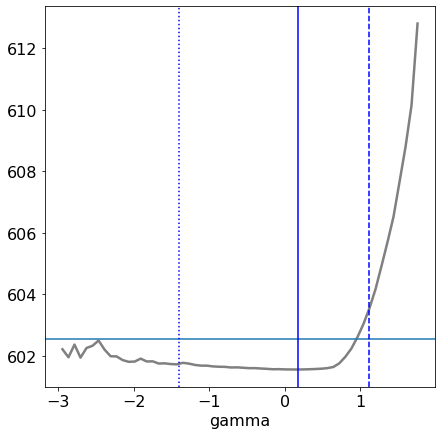

In [172]:
filepath ="/local/mariacst/2022_exoplanets/results/gNFW/Tcut650_NL_longer/"
nBDs=100; rank=39; gamma=1.3; sigma=0.1; ex="T650_NL_gNFW_longerPriorG"
_file    = filepath + "%i/"%rank + ex + "_N%i_sigma%.1f_gamma%.1f_rs10.0_v%ipost_equal_weights.dat"%(nBDs, sigma, gamma, rank)
samples = np.genfromtxt(_file, unpack=True)


fig, ax = plt.subplots(1, 1, figsize=(7, 7))

#like, x_bin, LI_max, LI_low, LI_high = plotting_like(samples, 0)
#ax[0].plot(x_bin, like, lw=2.5, color="grey")
#ax[0].axvline(LI_max, color="blue"); ax[0].axvline(LI_low, ls=":", color="blue")
#ax[0].axvline(LI_high, ls="--", color="blue"); ax[0].set_xlabel("f")

like, x_bin, LI_max, LI_low, LI_high = plotting_like(samples, 1, bin_n=60)
print(LI_low, LI_high)
ax.plot(x_bin, like, lw=2.5, color="grey")
ax.axhline(np.min(like[~np.isnan(like)])+1.); print(np.max(like[~np.isnan(like)]))
ax.axvline(LI_max, color="blue"); ax.axvline(LI_low, ls=":", color="blue")
ax.axvline(LI_high, ls="--", color="blue"); ax.set_xlabel("gamma")

#like, x_bin, LI_max, LI_low, LI_high = plotting_like(samples, 2)
#ax[2].plot(x_bin, like, lw=2.5, color="grey")
#ax[2].axvline(LI_max, color="blue"); ax[2].axvline(LI_low, ls=":", color="blue")
#ax[2].axvline(LI_high, ls="--", color="blue"); ax[2].set_xlabel("Rs [kpc]")

-2.651 -0.4588


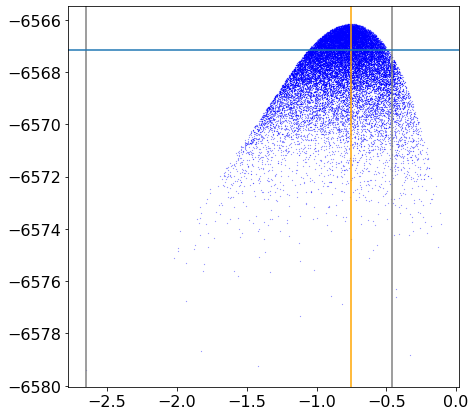

In [47]:
filepath ="/local/mariacst/2022_exoplanets/results/gNFW/Tcut650_NL_longer/"
rank=1; sigma=0.3; _rs=5.

gamma=1.1;
_file   = filepath + "%i/T650_NL_gNFW_longerPriorG_N1000_sigma%.1f_gamma%.1f_rs5.0_v%ipost_equal_weights.dat"%(rank, sigma, gamma, rank)
samples2 = np.genfromtxt(_file, unpack=True)
ex="T650_NL_gNFW_longerPriorG"
path = "/home/mariacst/exoplanets/results/gNFW/"
data = np.genfromtxt(path + "statistics_" + ex + ("_N%i_sigma%.1f_gamma%.1frs%.1f"%(1000, sigma, gamma, _rs)), unpack=True) 
low2 = data[4]; high2 = data[5]


fig, ax = plt.subplots(1, 1, figsize=(7, 7), sharey=True)

ax.scatter(samples2[1], samples2[3], marker=".", color="blue", s=0.1)
ax.axvline(samples2[1][np.argmax(samples2[3])], color="orange")
ax.axvline(low2[rank-1], color="grey"); ax.axvline(high2[rank-1], color="grey")
print(low2[rank-1], high2[rank-1])
ax.axhline(np.max(samples2[3])-1.)
#ax[1].set_ylim(1.45, 1.8)

/home/mariacst/exoplanets/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:55: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "background" which is no longer supported as of 3.3 and will become an error two minor releases later


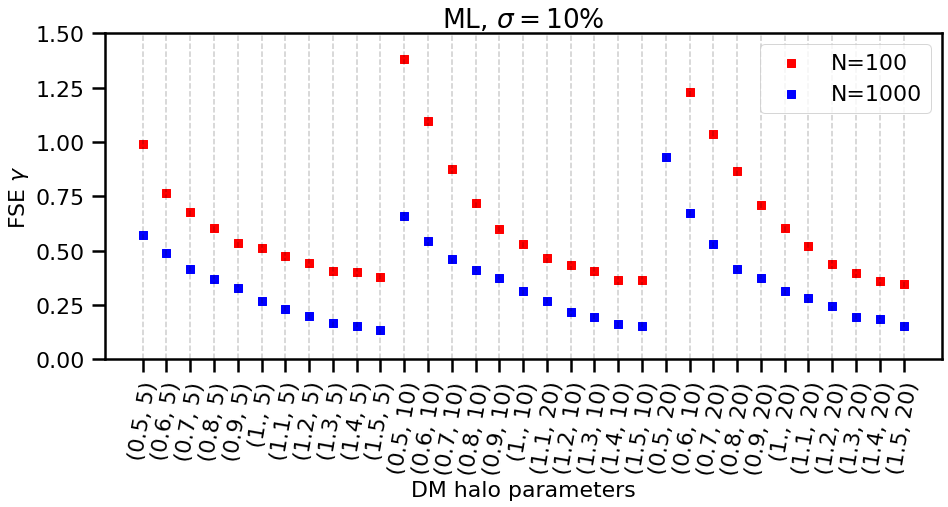

In [10]:
import imp
import utils_plots
imp.reload(utils_plots)

from utils_plots import FSE_f_gamma_rs_gNFW


#IMPORTANT CHANGE UTILS_PLOTS INPUT STAT FILE!!!

path = "/home/mariacst/exoplanets/results/gNFW/"

nBDs = [100, 1000]
sigma = 0.1

gamma = [0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1, 1.2, 1.3, 1.4, 1.5]
rs    = [5, 10, 20]
x1    = np.linspace(0, 1, 33);

color  = ["red", "blue"]
marker = ["o", "s", "<", "d"]

j=0

fig, ax = plt.subplots(1, 1, figsize=(15, 6))    
i=0
for N in nBDs:
    xi, yi, zi = FSE_f_gamma_rs_gNFW(path, N, sigma, "baseline_NL_gNFW", _gamma=True)    
    ax.scatter(x1, np.ravel(zi), color=color[i], marker="s", label="N=%i"%N, s=70.)
    
    i+=1
j+=1

for axis in ['top','bottom','left','right']:                                    
    ax.spines[axis].set_linewidth(2.5) 
ax.tick_params(which='major',direction="out",width=2.5,length=13,right=False,top=False,pad=7)

for i in x1:
    ax.axvline(i, ls="--", alpha=0.2, color="k")

ax.legend()
ax.set_xticks(x1) 
ax.set_xticklabels(['(0.5, 5)', '(0.6, 5)', '(0.7, 5)', '(0.8, 5)', '(0.9, 5)', 
                        '(1., 5)', '(1.1, 5)', '(1.2, 5)', '(1.3, 5)', '(1.4, 5)', '(1.5, 5)',
                       '(0.5, 10)', '(0.6, 10)', '(0.7, 10)', '(0.8, 10)', '(0.9, 10)', 
                        '(1., 10)', '(1.1, 20)', '(1.2, 10)', '(1.3, 10)', '(1.4, 10)', '(1.5, 10)', 
                        '(0.5, 20)', '(0.6, 10)', '(0.7, 20)', '(0.8, 20)', '(0.9, 20)', 
                        '(1., 20)', '(1.1, 20)', '(1.2, 20)', '(1.3, 20)', '(1.4, 20)', '(1.5, 20)', 
                       ], 
                   rotation=80);

ax.set_ylim(0, 1.)
ax.set_ylabel(r"FSE $\gamma$"); ax.set_xlabel("DM halo parameters")
ax.set_title(r"ML, $\sigma=%i$"%(int(sigma*100)) + "$\%$")
ax.set_ylim(0., 1.5)
fig.savefig("baseline_NL_gNFW_sigma%.1f.png"%sigma, bbox_inches="tight", background="transparent")

In [ ]:
from _utils import T_DM, delta_temperature_withDM                               
from _utils import sigma_Tmodel2, delta_sigma_Tmodel2

conv_Msun_to_kg = 1.98841e+30

def LogLikelihood(r, sigmar, M, sigmaM, A, sigmaA, Teff, 
                  a, b, c,
                  gamma, rs, f=1., rho0=0.42, v=100.):                                                 
                                                                       
    # DM temperature [K]                                                       
    TDM = T_DM(r, M=M*conv_Msun_to_kg, f=f, params=[gamma, rs, rho0], v=v)                        
    # total temperature [K]                                                    
    Ttot = np.power(np.power(Teff, 4) + np.power(TDM, 4), 0.25)           
                                                                               
    Ttot_corr = Ttot + delta_temperature_withDM(r, M, A, sigmar, sigmaM, sigmaA, Teff, TDM,  
                    f, [gamma, rs, rho0], a, b, c, v)                                                    
                                                                               
    sigmaT2_corr = (sigma_Tmodel2(r, M, A, sigmar,         
                        self.sigmaM, self.sigmaA, self.Teff, TDM, Ttot,        
                        f, [gamma, rs, self.rho0], self.a, self.b, self.c,  
                        self.v) +                                              
                delta_sigma_Tmodel2(self.r, self.M, self.A, self.sigmar,     
                    self.sigmaM, self.sigmaA, self.Teff, TDM, Ttot,            
                    f, [gamma, rs, self.rho0], self.a, self.b, self.b1,     
                    self.c, self.c1, self.v))                                  
                                                                               
    norm = (-0.5*self.ndata*np.log(2*np.pi)                                    
            - 0.5*np.sum(np.log(self.Terr**2 + sigmaT2_corr)))                 
    chi2 = np.sum((Ttot_corr-self.T)**2/(self.Terr**2 + sigmaT2_corr))         
    #print(norm-0.5*chi2)                                                      
    # return                                                                       
    return (norm-0.5*chi2) 

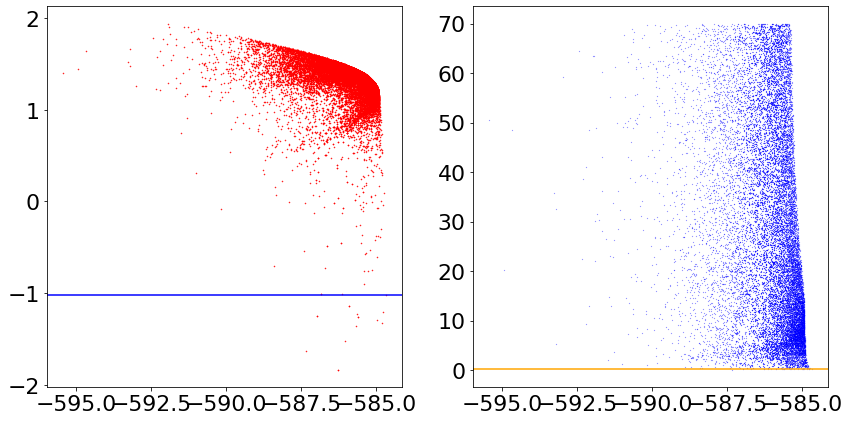

In [40]:
filepath ="/local/mariacst/2022_exoplanets/results/gNFW/baseline_NL_longer/"
rank=4; gamma=1.5; sigma=0.1
_file   = filepath + "%i/baseline_NL_gNFW_longerPriorG_N100_sigma%.1f_gamma%.1f_rs20.0_v%ipost_equal_weights.dat"%(rank, sigma, gamma, rank)
samples1 = np.genfromtxt(_file, unpack=True)



fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].scatter(samples1[3], samples1[1], marker=".", color="red", s=1)
ax[0].axhline(samples1[1][np.argmax(samples1[3])], color="blue")
#ax[0].set_ylim(1.45, 1.8)

ax[1].scatter(samples1[3], samples1[2], marker=".", color="blue", s=0.1)
ax[1].axhline(samples1[2][np.argmax(samples1[3])], color="orange")
#ax[1].set_ylim(0, 2)

In [16]:
!ls /local/mariacst/2022_exoplanets/results/gNFW/

Tcut650_NL.tar.gz  Tcut650_NL_longer  baseline_NL.tar.gz  baseline_NL_longer


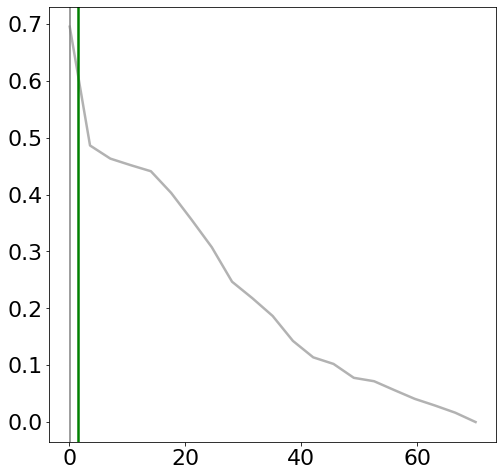

In [49]:
def plot_LI(L, samples, ax, color="grey", bin_n=20):
    x = binned_statistic(samples, -L, 'min', bins=bin_n)[1]                     
    y = binned_statistic(samples, -L, 'min', bins=bin_n+1)[0]                   
                                                                                
    # Create Interpolation fanction Likelihood - parameter                      
    #pdb.set_trace()                                                            
    z =  UnivariateSpline(x[~np.isnan(y)], y[~np.isnan(y)], s=0) 
    
    ax.plot(x, -z(x)+(np.max(z(x))), color=color, lw=2.5, alpha=0.6)
    ax.axvline(x[np.argmin(z(x))], color=color)
    return

fig, ax = plt.subplots(1, 1, figsize=(8, 8), sharex=True)

gamma=1.5; sigma=0.1

filepath ="/local/mariacst/2022_exoplanets/results/gNFW/baseline_NL_longer/"

for rank in [4]:#, 6, 7, 8, 9]:

    _file   = filepath + "%i/baseline_NL_gNFW_longerPriorG_N100_sigma%.1f_gamma%.1f_rs20.0_v%ipost_equal_weights.dat"%(rank, sigma, gamma, rank)
    samples1 = np.genfromtxt(_file, unpack=True)

    #_file   = filepath + "%i/baseline_NL_gNFW_longerPriorG_N1000_sigma%.1f_gamma%.1f_rs20.0_v%ipost_equal_weights.dat"%(rank, sigma, gamma, rank)
    #samples2 = np.genfromtxt(_file, unpack=True)


    plot_LI(samples1[3], samples1[2], ax, bin_n=20)
    #plot_LI(samples2[3], samples2[1], ax[1], bin_n=20)
    
    
    
ax.axvline(gamma, lw=2.5, color="green")
#ax[1].axvline(gamma, lw=2.5, color="green")

For normal run, 0.53  0.45
For longer prior range, 0.57  0.45


Text(0.5, 0, '$\\gamma$')

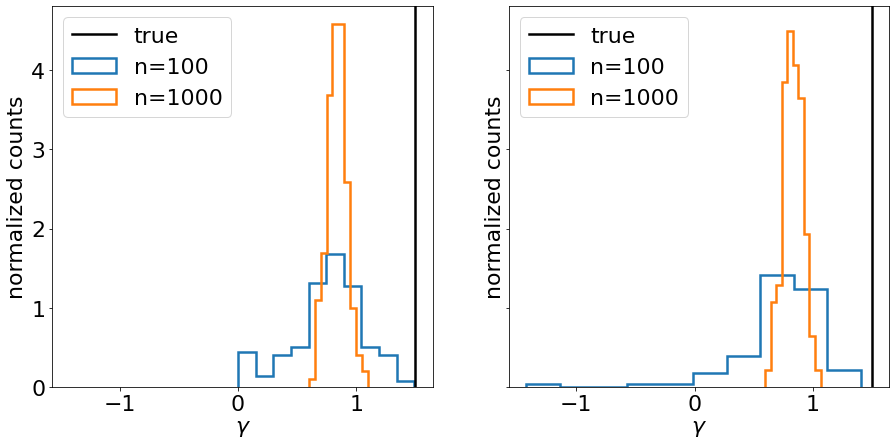

In [46]:
path = "/home/mariacst/exoplanets/results/gNFW/"

fig, ax = plt.subplots(1, 2, figsize=(15, 7), sharex=True, sharey=True)
ex="T650_NL_gNFW"
_g = 1.5; _rs=20.; n=100
s=0.1
data = np.genfromtxt(path + "statistics_" + ex + ("_N%i_sigma%.1f_gamma%.1frs%.1f"%(n, s, _g, _rs)),
                     unpack=True) 
pe1 = data[3]

n=1000
data = np.genfromtxt(path + "statistics_" + ex + ("_N%i_sigma%.1f_gamma%.1frs%.1f"%(n, s, _g, _rs)),
                     unpack=True) 
pe2 = data[3]
FSE1 = np.sqrt(1/len(pe1)*np.sum(np.power(pe1 - _g, 2)))/_g
FSE2 = np.sqrt(1/len(pe2)*np.sum(np.power(pe2 - _g, 2)))/_g
print("For normal run, %.2f  %.2f"%(FSE1, FSE2))
ax[0].hist(pe1, histtype="step", label="n=100", lw=2.5, density=True); 
ax[0].hist(pe2, histtype="step", label="n=1000", lw=2.5, density=True)

ax[0].axvline(_g, color="k", label="true", lw=2.5); ax[0].legend(loc="upper left")
ax[0].set_ylabel("normalized counts"); ax[0].set_xlabel(r"$\gamma$")

ex="T650_NL_gNFW_longerPriorG"
n=100
data = np.genfromtxt(path + "statistics_" + ex + ("_N%i_sigma%.1f_gamma%.1frs%.1f"%(n, s, _g, _rs)),
                     unpack=True) 
pe1 = data[3]

n=1000
data = np.genfromtxt(path + "statistics_" + ex + ("_N%i_sigma%.1f_gamma%.1frs%.1f"%(n, s, _g, _rs)),
                     unpack=True) 
pe2 = data[3]

FSE1 = np.sqrt(1/len(pe1)*np.sum(np.power(pe1 - _g, 2)))/_g
FSE2 = np.sqrt(1/len(pe2)*np.sum(np.power(pe2 - _g, 2)))/_g
print("For longer prior range, %.2f  %.2f"%(FSE1, FSE2))


#ax[1].axvline(FSE1, color="red")
ax[1].hist(pe1, histtype="step", label="n=100", lw=2.5, density=True); 
ax[1].hist(pe2, histtype="step", label="n=1000", lw=2.5, density=True)

ax[1].axvline(_g, color="k", label="true", lw=2.5); ax[1].legend(loc="upper left")
ax[1].set_ylabel("normalized counts"); ax[1].set_xlabel(r"$\gamma$")

In [14]:
!ls /local/mariacst/2022_exoplanets/results/gNFW/

Tcut650_NL.tar.gz  Tcut650_NL_longer  baseline_NL.tar.gz  baseline_NL_longer


-0.8357 0.0846


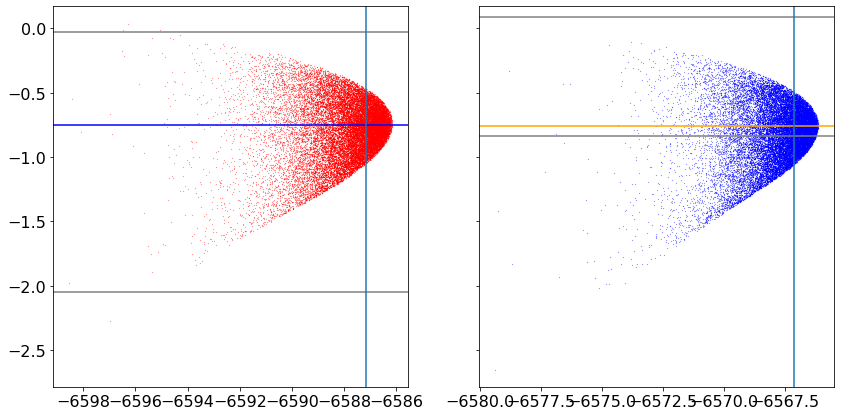

In [38]:
filepath ="/local/mariacst/2022_exoplanets/results/gNFW/Tcut650_NL_longer/"
rank=1; gamma=1.; sigma=0.3
_file   = filepath + "%i/T650_NL_gNFW_longerPriorG_N1000_sigma%.1f_gamma%.1f_rs5.0_v%ipost_equal_weights.dat"%(rank, sigma, gamma, rank)
samples1 = np.genfromtxt(_file, unpack=True)

ex="T650_NL_gNFW_longerPriorG"; _rs=5.
path = "/home/mariacst/exoplanets/results/gNFW/"
data = np.genfromtxt(path + "statistics_" + ex + ("_N%i_sigma%.1f_gamma%.1frs%.1f"%(1000, sigma, gamma, _rs)), unpack=True) 
low1 = data[4]; high1 = data[5]


gamma=1.1;
_file   = filepath + "%i/T650_NL_gNFW_longerPriorG_N1000_sigma%.1f_gamma%.1f_rs5.0_v%ipost_equal_weights.dat"%(rank, sigma, gamma, rank)
samples2 = np.genfromtxt(_file, unpack=True)
ex="T650_NL_gNFW_longerPriorG"
path = "/home/mariacst/exoplanets/results/gNFW/"
data = np.genfromtxt(path + "statistics_" + ex + ("_N%i_sigma%.1f_gamma%.1frs%.1f"%(1000, sigma, gamma, _rs)), unpack=True) 
low2 = data[4]; high2 = data[5]


fig, ax = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
ax[0].scatter(samples1[3], samples1[1], marker=".", color="red", s=0.1)
ax[0].axhline(samples1[1][np.argmax(samples1[3])], color="blue")
ax[0].axhline(low1[rank], color="grey"); ax[0].axhline(high1[rank], color="grey")
ax[0].axvline(np.max(samples1[3])-1.)
#ax[0].set_ylim(1.45, 1.8)

ax[1].scatter(samples2[3], samples2[1], marker=".", color="blue", s=0.1)
ax[1].axhline(samples2[1][np.argmax(samples2[3])], color="orange")
ax[1].axhline(low2[rank], color="grey"); ax[1].axhline(high2[rank], color="grey")
print(low2[rank], high2[rank])
ax[1].axvline(np.max(samples2[3])-1.)
#ax[1].set_ylim(1.45, 1.8)

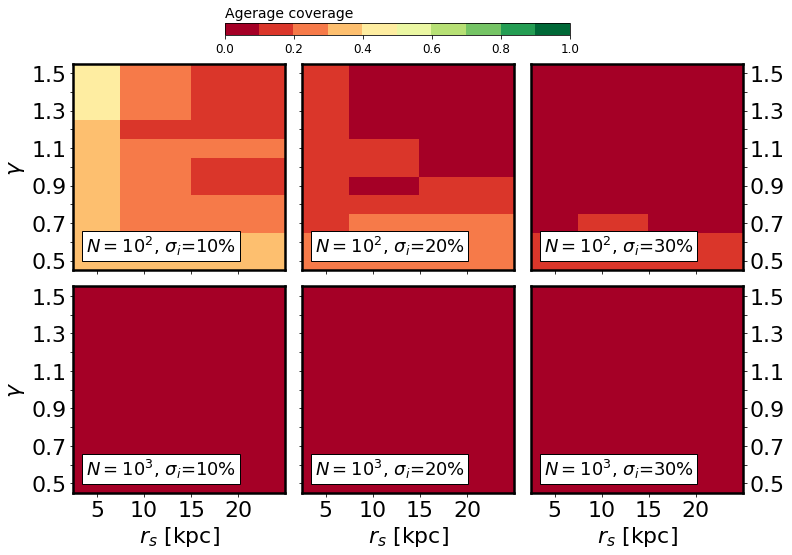

In [10]:
path = "/home/mariacst/exoplanets/results/gNFW/"
ex   = "T650_NL_gNFW_longerPriorG"
pe   = "LI"
import imp, utils_plots
imp.reload(utils_plots)
from utils_plots import grid_coverage

fig, ax = plt.subplots(2, 3, figsize=(12, 8))
cs = grid_coverage(path, 100, 0.1,  ex, ax[0, 0], pe, ylabel=True, xlabel=False, _gNFW=True)
grid_coverage(path, 1000, 0.1, ex, ax[1, 0], pe, ylabel=True, xlabel=True, _gNFW=True)
grid_coverage(path, 100, 0.2,  ex, ax[0, 1], pe, ylabel=False, xlabel=False, _gNFW=True)
grid_coverage(path, 1000, 0.2, ex, ax[1, 1], pe, ylabel=False, xlabel=True, _gNFW=True)
grid_coverage(path, 100, 0.3,  ex, ax[0, 2], pe, ylabel=False, xlabel=False, _gNFW=True)
grid_coverage(path, 1000, 0.3, ex, ax[1, 2], pe, ylabel=False, xlabel=True, _gNFW=True)

ax[0, 2].set_yticklabels(['0.5', '', '0.7', '', '0.9', '', '1.1', '', '1.3', '', '1.5'])
ax[1, 2].set_yticklabels(['0.5', '', '0.7', '', '0.9', '', '1.1', '', '1.3', '', '1.5'])
ax[0, 2].yaxis.tick_right(); ax[1, 2].yaxis.tick_right()  

fig.subplots_adjust(top=0.87)
cbar_ax = fig.add_axes([0.3, 0.92, 0.4, 0.02])
cbar = fig.colorbar(cs, cax=cbar_ax, orientation="horizontal")    
cbar.ax.tick_params(labelsize=12)
cbar.ax.set_title(r"Agerage coverage", size=14., loc="left")

fig.subplots_adjust(wspace=0.08, hspace=0.08)
fig.savefig("coverage_" + ex + pe + ".png", transparent=True)

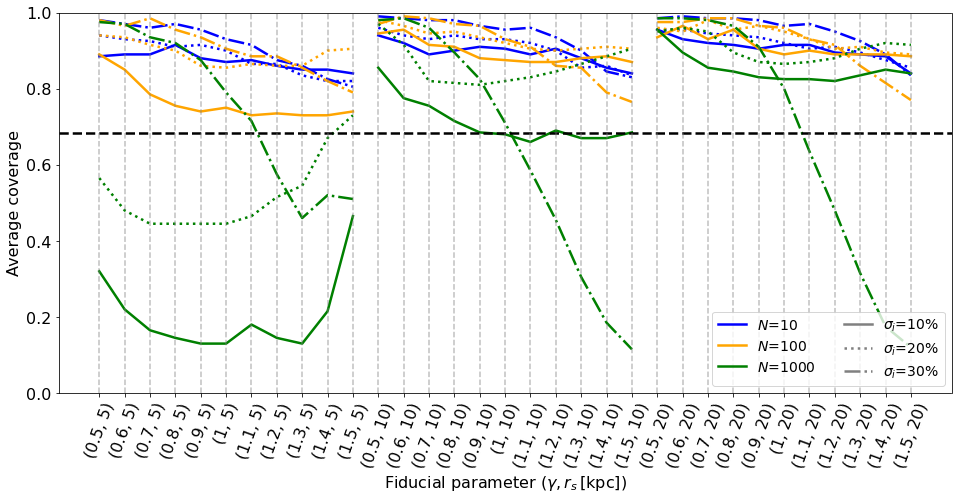

In [12]:
def plot_coverage_pe(path, ex, n, s, pe, fig=None, ax=None, color=None, ls=None):

    if not fig:
        fig, ax = plt.subplots(1, 1, figsize=(11, 5)) 
    #ax.set_title(pe)
    x=0
    if color is None:
        if n<200:
            color="red"
        else:
            color="blue"
    i = 0
    for _rs in rs:
        cove = []; x = [];
        for _g in gamma:
            try:
                data = np.genfromtxt(path + "statistics_" + ex +           
                         ("_N%i_sigma%.1f_gamma%.1frs%.1f"%(n, s, _g, _rs)), unpack=True) 
            except:
                data = np.genfromtxt(path + "statistics_" + ex +           
                         ("_N%i_sigma%.1f_gamma%.1frs%.1f"%(n, s, _g, _rs)), unpack=True)  
            if pe=="LI":                                                       
                low  = data[10]
                high = data[11]
            else:                                                                  
                sys.exit("Interval not implemented!") 
                
            one = _g > low
            two = _g < high
            
            cove.append(len(np.where((one==True) & (two==True))[0])/len(data[0]))
            x.append(i); i+=1
                                    
        ax.plot(x, cove, color=color, ls=ls, lw=2.5)#, label="N=%i"%n)
    return fig, ax


rc('font', family='times new roman', size=16.)

path = "/home/mariacst/exoplanets/results/power_law/older_BD/"
ex   = "baseline_NL_olderBD"
pe   = "LI"

gamma = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
rs    = [5, 10, 20]

x_axis = np.arange(0, 33)

fig, ax = plt.subplots(1, 1, figsize=(16, 7))

plot_coverage_pe(path, ex, 10, 0.1, pe, fig, ax, color="blue", ls="-")
plot_coverage_pe(path, ex, 10, 0.2, pe, fig, ax, color="blue", ls=":")
plot_coverage_pe(path, ex, 10, 0.3, pe, fig, ax, color="blue", ls="-.")
plot_coverage_pe(path, ex, 100, 0.1, pe, fig, ax, color="orange", ls="-")
plot_coverage_pe(path, ex, 100, 0.2, pe, fig, ax, color="orange", ls=":")
plot_coverage_pe(path, ex, 100, 0.3, pe, fig, ax, color="orange", ls="-.")
plot_coverage_pe(path, ex, 1000, 0.1, pe, fig, ax, color="green", ls="-")
plot_coverage_pe(path, ex, 1000, 0.2, pe, fig, ax, color="green", ls=":")
plot_coverage_pe(path, ex, 1000, 0.3, pe, fig, ax, color="green", ls="-.")


ax.axhline(0.683, lw=2.5, ls="--", color="black"); #ax.axhline(0.954, lw=2.5, ls="--", color="black")
ax.set_xticks(x_axis) 
#ax.set_xticklabels(['(1.2, 5)', '(1.4, 5)', '(1.5, 5)',
#                    '(1.2, 20)', '(1.4, 20)', '(1.5, 20)'
#                   ], rotation=80);
ax.set_xticklabels(['(0.5, 5)', '(0.6, 5)', '(0.7, 5)', '(0.8, 5)', '(0.9, 5)', '(1, 5)', '(1.1, 5)', '(1.2, 5)', '(1.3, 5)', '(1.4, 5)', '(1.5, 5)',
                    '(0.5, 10)', '(0.6, 10)', '(0.7, 10)', '(0.8, 10)', '(0.9, 10)', '(1, 10)', '(1.1, 10)', '(1.2, 10)', '(1.3, 10)', '(1.4, 10)', '(1.5, 10)',
                    '(0.5, 20)', '(0.6, 20)', '(0.7, 20)', '(0.8, 20)', '(0.9, 20)', '(1, 20)', '(1.1, 20)', '(1.2, 20)', '(1.3, 20)', '(1.4, 20)', 
                    '(1.5, 20)'], rotation=70)
ax.set_ylim(0., 1.)
ax.set_ylabel("Average coverage"); ax.set_xlabel(r"Fiducial parameter $(\gamma, r_s{\,\rm [kpc]})$")
for x in x_axis:
    ax.axvline(x, ls="--", color="grey", alpha=0.5)
    
legend_elements = [Line2D([0], [0], color='blue', lw=2.5, label='$N$=10'),
                   Line2D([0], [0], color='orange', lw=2.5, label='$N$=100'),
                   Line2D([0], [0], color='green', lw=2.5, label='$N$=1000'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle="-", label='$\sigma_i$=10%'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle=":", label='$\sigma_i$=20%'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle="-.", label='$\sigma_i$=30%')]

ax.legend(handles=legend_elements, ncol=2, loc='lower right', fontsize=14)
fig.savefig("coverage2_" + ex + pe + ".pdf", transparent=True, bbox_inches="tight")

# Power-law

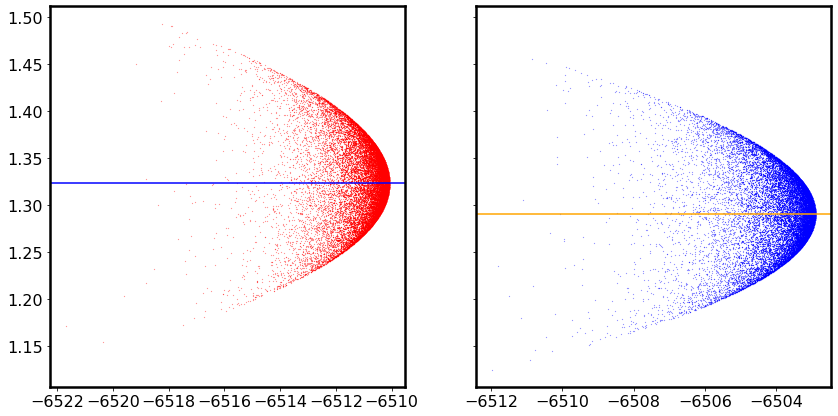

In [94]:
filepath ="/local/mariacst/2022_exoplanets/results/power_law/v30/baseline_NL_older/"
rank=1; gamma=1.5; sigma=0.3
_file   = filepath + "1/baseline_NL_olderBD_v30_N1000_sigma0.3_gamma1.5_rs5.0_v1post_equal_weights.dat"
samples1 = np.genfromtxt(_file, unpack=True)


_file   = filepath + "106/baseline_NL_olderBD_v30_N1000_sigma0.3_gamma1.5_rs5.0_v106post_equal_weights.dat"
samples2 = np.genfromtxt(_file, unpack=True)


fig, ax = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
ax[0].scatter(samples1[2], samples1[1], marker=".", color="red", s=0.1)
ax[0].axhline(samples1[1][np.argmax(samples1[2])], color="blue")
ax[1].axhline(samples2[1][np.argmax(samples2[2])], color="orange")
#ax[0].set_ylim(1.45, 1.8)

ax[1].scatter(samples2[2], samples2[1], marker=".", color="blue", s=0.1)
#ax[1].axhline(samples2[1][np.argmax(samples2[2])], color="orange")
#ax[1].set_ylim(1.45, 1.8)

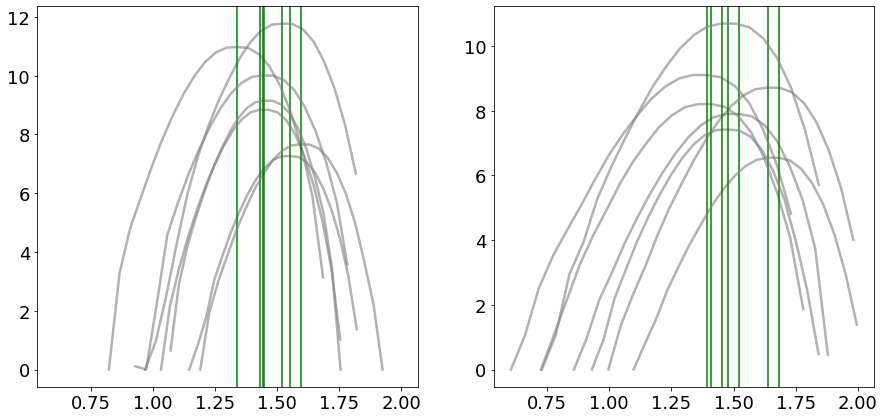

In [15]:
def plot_LI(L, samples, ax, color="grey", bin_n=30):
    x = binned_statistic(samples, -L, 'min', bins=bin_n)[1]                     
    y = binned_statistic(samples, -L, 'min', bins=bin_n+1)[0]                   
                                                                                
    # Create Interpolation fanction Likelihood - parameter                      
    #pdb.set_trace()                                                            
    z =  UnivariateSpline(x[~np.isnan(y)], y[~np.isnan(y)], s=0) 
    
    ax.plot(x, -z(x)+(np.max(z(x))), color=color, lw=2.5, alpha=0.6)
    ax.axvline(x[np.argmin(z(x))], color="green")
    return

fig, ax = plt.subplots(1, 2, figsize=(15, 7), sharex=True)

gamma=1.5; 
filepath ="/hdfs/local/mariacst/2022_exoplanets/results/power_law/baseline_NL/"

for rank in [1, 100, 102, 103, 104, 105, 111]:
    
    sigma=0.1
    _file   = filepath + "%i/baseline_NL_log_N100_sigma%.1f_gamma%.1f_rs5.0_v%ipost_equal_weights.dat"%(rank, sigma, gamma, rank)
    samples1 = np.genfromtxt(_file, unpack=True)
    sigma=0.2
    _file   = filepath + "%i/baseline_NL_log_N100_sigma%.1f_gamma%.1f_rs5.0_v%ipost_equal_weights.dat"%(rank, sigma, gamma, rank)
    samples2 = np.genfromtxt(_file, unpack=True)


    plot_LI(samples1[2], samples1[0], ax[0], bin_n=20)
    plot_LI(samples2[2], samples2[0], ax[1], bin_n=20)
    
    
#ax[0].axvline(gamma, lw=2.5, color="red")
#ax[1].axvline(gamma, lw=2.5, color="red")

In [2]:
import utils_plots
import imp
imp.reload(utils_plots)
from utils_plots import grid_MARE

/home/mariacst/exoplanets/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  del sys.path[0]


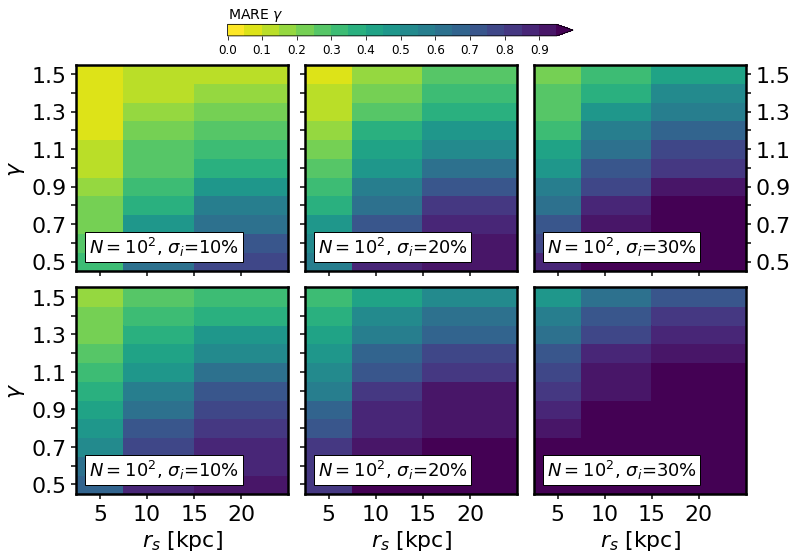

In [6]:
path = "/home/mariacst/exoplanets/results/power_law/older_BD/v30/"
ex   = "T650_NL_olderBD_v30"

for pe in ["ML"]:
    fig, ax = plt.subplots(2, 3, figsize=(12, 8))
    cs = grid_MARE(path, 100, 0.1,  ex, ax[0, 0], pe, ylabel=True, xlabel=False)
    grid_MARE(path, 100, 0.2,  ex, ax[0, 1], pe, ylabel=False, xlabel=False)
    
    grid_MARE(path, 100, 0.3,  ex, ax[0, 2], pe, ylabel=False, xlabel=False)
    
    #ax[0, 0].set_title(pe)
    ax[0, 2].set_yticklabels(['0.5', '', '0.7', '', '0.9', '', '1.1', '', '1.3', '', '1.5'])
    ax[1, 2].set_yticklabels(['0.5', '', '0.7', '', '0.9', '', '1.1', '', '1.3', '', '1.5'])
    ax[0, 2].yaxis.tick_right(); ax[1, 2].yaxis.tick_right()

path = "/home/mariacst/exoplanets/results/power_law/older_BD/"   
ex   = "T650_NL_olderBD"
for pe in ["ML"]:
    grid_MARE(path, 100, 0.1, ex, ax[1, 0], pe, ylabel=True, xlabel=True)
    grid_MARE(path, 100, 0.2, ex, ax[1, 1], pe, ylabel=False, xlabel=True)
    grid_MARE(path, 100, 0.3, ex, ax[1, 2], pe, ylabel=False, xlabel=True)
    
    fig.subplots_adjust(top=0.87)
    cbar_ax = fig.add_axes([0.3, 0.92, 0.4, 0.02])
    cbar = fig.colorbar(cs, cax=cbar_ax, orientation="horizontal")
    
    cbar.ax.tick_params(labelsize=12)
    cbar.ax.set_title(r"MARE $\gamma$", size=14., loc="left")
    
    fig.subplots_adjust(wspace=0.08, hspace=0.08)

/home/mariacst/exoplanets/exoplanets/python/utils_plots.py:318: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['5', '10', '15', '20'])


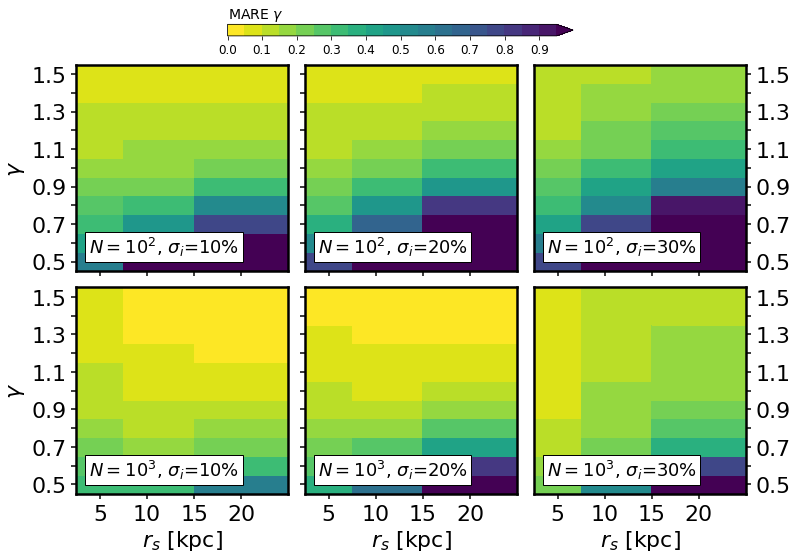

In [4]:
path = "/home/mariacst/exoplanets/results/power_law/older_BD/v30/"
ex   = "baseline_NL_olderBD_v30"

for pe in ["ML"]:
    fig, ax = plt.subplots(2, 3, figsize=(12, 8))
    cs = grid_MARE(path, 100, 0.1,  ex, ax[0, 0], pe, ylabel=True, xlabel=False)
    grid_MARE(path, 1000, 0.1, ex, ax[1, 0], pe, ylabel=True, xlabel=True)
    grid_MARE(path, 100, 0.2,  ex, ax[0, 1], pe, ylabel=False, xlabel=False)
    grid_MARE(path, 1000, 0.2, ex, ax[1, 1], pe, ylabel=False, xlabel=True)
    grid_MARE(path, 100, 0.3,  ex, ax[0, 2], pe, ylabel=False, xlabel=False)
    grid_MARE(path, 1000, 0.3, ex, ax[1, 2], pe, ylabel=False, xlabel=True)
    #ax[0, 0].set_title(pe)
    ax[0, 2].set_yticklabels(['0.5', '', '0.7', '', '0.9', '', '1.1', '', '1.3', '', '1.5'])
    ax[1, 2].set_yticklabels(['0.5', '', '0.7', '', '0.9', '', '1.1', '', '1.3', '', '1.5'])
    ax[0, 2].yaxis.tick_right(); ax[1, 2].yaxis.tick_right()
    
    
    fig.subplots_adjust(top=0.87)
    cbar_ax = fig.add_axes([0.3, 0.92, 0.4, 0.02])
    cbar = fig.colorbar(cs, cax=cbar_ax, orientation="horizontal")
    
    cbar.ax.tick_params(labelsize=12)
    cbar.ax.set_title(r"MARE $\gamma$", size=14., loc="left")
    
    fig.subplots_adjust(wspace=0.08, hspace=0.08)
    
    #fig.savefig("MARE_" + ex + pe + ".png", transparent=True)

In [101]:
import utils_plots
import imp
imp.reload(utils_plots)
from utils_plots import grid_FSE

[[ 2.5  2.5  2.5  2.5  2.5  2.5  2.5  2.5  2.5  2.5  2.5  2.5]
 [ 7.5  7.5  7.5  7.5  7.5  7.5  7.5  7.5  7.5  7.5  7.5  7.5]
 [15.  15.  15.  15.  15.  15.  15.  15.  15.  15.  15.  15. ]
 [25.  25.  25.  25.  25.  25.  25.  25.  25.  25.  25.  25. ]] [[0.45 0.55 0.65 0.75 0.85 0.95 1.05 1.15 1.25 1.35 1.45 1.55]
 [0.45 0.55 0.65 0.75 0.85 0.95 1.05 1.15 1.25 1.35 1.45 1.55]
 [0.45 0.55 0.65 0.75 0.85 0.95 1.05 1.15 1.25 1.35 1.45 1.55]
 [0.45 0.55 0.65 0.75 0.85 0.95 1.05 1.15 1.25 1.35 1.45 1.55]]
[[0.12894489 0.10930806 0.09990606 0.09491971 0.09280215 0.09248155
  0.09398729 0.09683744 0.10070714 0.10534873 0.11043304]
 [0.29295245 0.2514978  0.22407905 0.20184414 0.18281691 0.16702877
  0.15493671 0.1464295  0.14101607 0.13808289 0.13705461]
 [0.45405353 0.36295894 0.31316417 0.27792115 0.24806604 0.22144455
  0.19882389 0.18108305 0.16812185 0.15932477 0.15366753]]


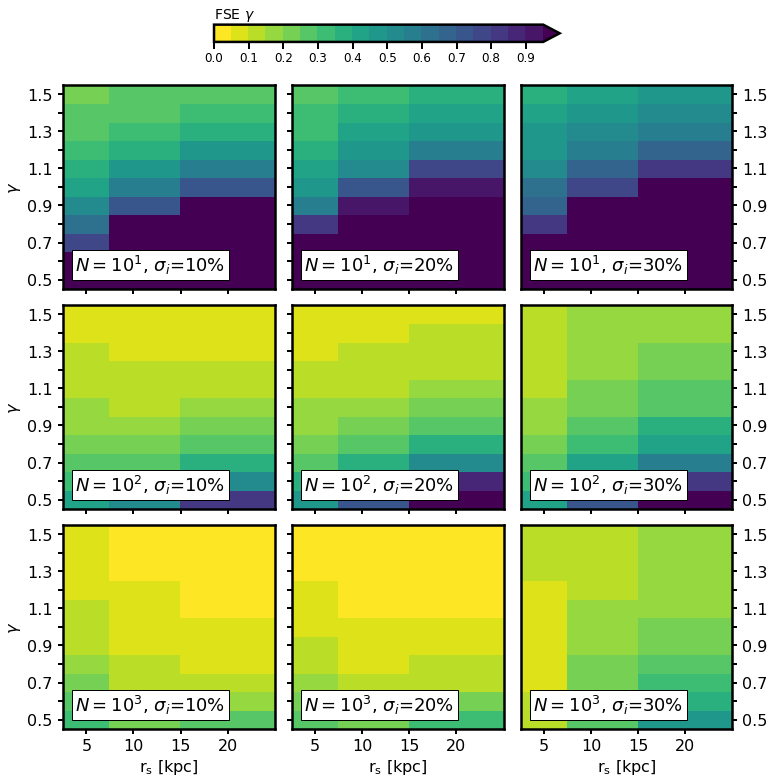

In [110]:
path = "/home/mariacst/exoplanets/results/power_law/older_BD/v30/"
ex   = "baseline_NL_olderBD_v30"

for pe in ["ML"]:
    fig, ax = plt.subplots(3, 3, figsize=(12, 12))
    
    grid_FSE(path, 10, 0.1, ex, ax[0, 0], pe, ylabel=True, xlabel=False)
    grid_FSE(path, 10, 0.2, ex, ax[0, 1], pe, ylabel=False, xlabel=False)
    grid_FSE(path, 10, 0.3, ex, ax[0, 2], pe, ylabel=False, xlabel=False)
    
    cs = grid_FSE(path, 100, 0.1,  ex, ax[1, 0], pe, ylabel=True, xlabel=False)
    grid_FSE(path, 1000, 0.1, ex, ax[2, 0], pe, ylabel=True, xlabel=True)
    grid_FSE(path, 100, 0.2,  ex, ax[1, 1], pe, ylabel=False, xlabel=False)
    grid_FSE(path, 1000, 0.2, ex, ax[2, 1], pe, ylabel=False, xlabel=True)
    grid_FSE(path, 100, 0.3,  ex, ax[1, 2], pe, ylabel=False, xlabel=False)
    grid_FSE(path, 1000, 0.3, ex, ax[2, 2], pe, ylabel=False, xlabel=True, show=True)

    ax[0, 2].set_yticklabels(['0.5', '', '0.7', '', '0.9', '', '1.1', '', '1.3', '', '1.5'])
    ax[1, 2].set_yticklabels(['0.5', '', '0.7', '', '0.9', '', '1.1', '', '1.3', '', '1.5'])
    ax[2, 2].set_yticklabels(['0.5', '', '0.7', '', '0.9', '', '1.1', '', '1.3', '', '1.5'])
    ax[0, 2].yaxis.tick_right(); ax[1, 2].yaxis.tick_right(); ax[2, 2].yaxis.tick_right()
    
    
    fig.subplots_adjust(top=0.87)
    cbar_ax = fig.add_axes([0.3, 0.92, 0.4, 0.02])
    cbar = fig.colorbar(cs, cax=cbar_ax, orientation="horizontal")
    
    cbar.ax.tick_params(labelsize=12, which='major',direction="out",width=2.,length=7,right=True,top=False,pad=3)    
    cbar.ax.set_title(r"FSE $\gamma$", size=14., loc="left")
    
    fig.subplots_adjust(wspace=0.08, hspace=0.08)
    
    #fig.savefig("FSE_" + ex + pe + "_with10.png", bbox_inches="tight")

In [112]:
def plot_FSE_pe(path, ex, n, s, pe="ML", fig=None, ax=None, color=None, ls=None):

    if not fig:
        fig, ax = plt.subplots(1, 1, figsize=(11, 5)) 
    #ax.set_title(pe)
    x=0
    if color is None:
        if n<200:
            color="red"
        else:
            color="blue"
    i = 0
    for _rs in rs:
        cove = []; x = [];
        for _g in gamma:
            data = np.genfromtxt(path + "statistics_" + ex +           
                   ("_N%i_sigma%.1f_gamma%.1frs%.1f"%(n, s, _g, _rs)), unpack=True) 
 
            if pe=="ML":                                                       
                _pe = data[9][:200]
            else:     
                sys.exit("Interval not implemented!") 
                
            rank = len(_pe);
            
            cove.append(np.sqrt(1/rank*np.sum(np.power(_pe - _g, 2)))/_g)
            x.append(i); i+=1
        print(x, cove)                          
        ax.plot(x, cove, color=color, ls=ls, lw=2.5)#, label="N=%i"%n)
    return fig, ax

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10] [0.12894488977854066, 0.1093080617388814, 0.09990606404344561, 0.09491971113788752, 0.09253892207479746, 0.09221481144588434, 0.09369560284098476, 0.09643382806071964, 0.10024352345205574, 0.10483074429278647, 0.10987970351454561]
[11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21] [0.29295245006655946, 0.25149780179070264, 0.22407904855206787, 0.20184414392669414, 0.182816905977295, 0.1670287714736596, 0.15493671395307998, 0.14642950498637747, 0.141016067740335, 0.1380828880766615, 0.1370546067165282]
[22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32] [0.45405352613981537, 0.3629589359234274, 0.31316416686486215, 0.27792114860828787, 0.24806603959429835, 0.22144455479871253, 0.1988238881834794, 0.18108305414919418, 0.16812185185455794, 0.15932476867475845, 0.15366752508798553]


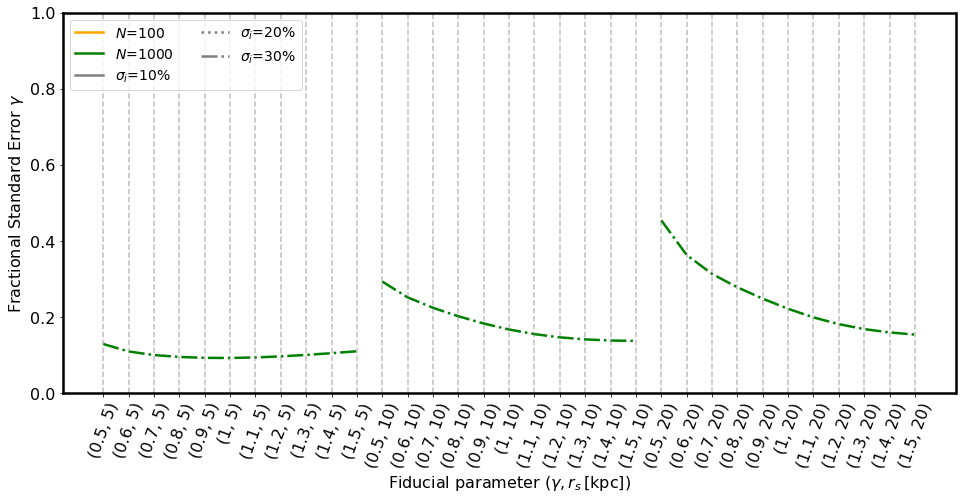

In [113]:
rc('font', family='times new roman', size=16.)

nBDs  = 100
sigma = 0.1

gamma = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
rs    = [5, 10., 20.]

x_axis = np.arange(0, 33)

from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, figsize=(16, 7))

path = "/home/mariacst/exoplanets/results/power_law/older_BD/v30/"
pe = "ML"; ex = "baseline_NL_olderBD_v30"

#plot_FSE_pe(path, ex, 10, 0.1, pe, fig, ax, color="blue", ls="-")
#plot_FSE_pe(path, ex, 10, 0.2, pe, fig, ax, color="blue", ls=":")
#plot_FSE_pe(path, ex, 10, 0.3, pe, fig, ax, color="blue", ls="-.")
#plot_FSE_pe(path, ex, 100, 0.1, pe, fig, ax, color="orange", ls="-")
#plot_FSE_pe(path, ex, 100, 0.2, pe, fig, ax, color="orange", ls=":")
#plot_FSE_pe(path, ex, 100, 0.3, pe, fig, ax, color="orange", ls="-.")
#plot_FSE_pe(path, ex, 1000, 0.1, pe, fig, ax, color="green", ls="-")
#plot_FSE_pe(path, ex, 1000, 0.2, pe, fig, ax, color="green", ls=":")
plot_FSE_pe(path, ex, 1000, 0.3, pe, fig, ax, color="green", ls="-.")


ax.set_xticks(x_axis) 
ax.set_xticklabels(['(0.5, 5)', '(0.6, 5)', '(0.7, 5)', '(0.8, 5)', '(0.9, 5)', '(1, 5)', '(1.1, 5)', '(1.2, 5)', '(1.3, 5)', '(1.4, 5)', '(1.5, 5)',
                    '(0.5, 10)', '(0.6, 10)', '(0.7, 10)', '(0.8, 10)', '(0.9, 10)', '(1, 10)', '(1.1, 10)', '(1.2, 10)', '(1.3, 10)', '(1.4, 10)', '(1.5, 10)',
                    '(0.5, 20)', '(0.6, 20)', '(0.7, 20)', '(0.8, 20)', '(0.9, 20)', '(1, 20)', '(1.1, 20)', '(1.2, 20)', '(1.3, 20)', '(1.4, 20)', 
                    '(1.5, 20)'], rotation=70)
ax.set_ylim(0., 1.)
ax.axhline(1., color="k", ls=":")
ax.set_ylabel("Fractional Standard Error $\gamma$"); ax.set_xlabel(r"Fiducial parameter $(\gamma, r_s{\,\rm [kpc]})$")
for x in x_axis:
    ax.axvline(x, ls="--", color="grey", alpha=0.5)
    
legend_elements = [Line2D([0], [0], color='orange', lw=2.5, label='$N$=100'),
                   Line2D([0], [0], color='green', lw=2.5, label='$N$=1000'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle="-", label='$\sigma_i$=10%'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle=":", label='$\sigma_i$=20%'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle="-.", label='$\sigma_i$=30%')]

ax.legend(handles=legend_elements, ncol=2, loc='upper left', fontsize=14)

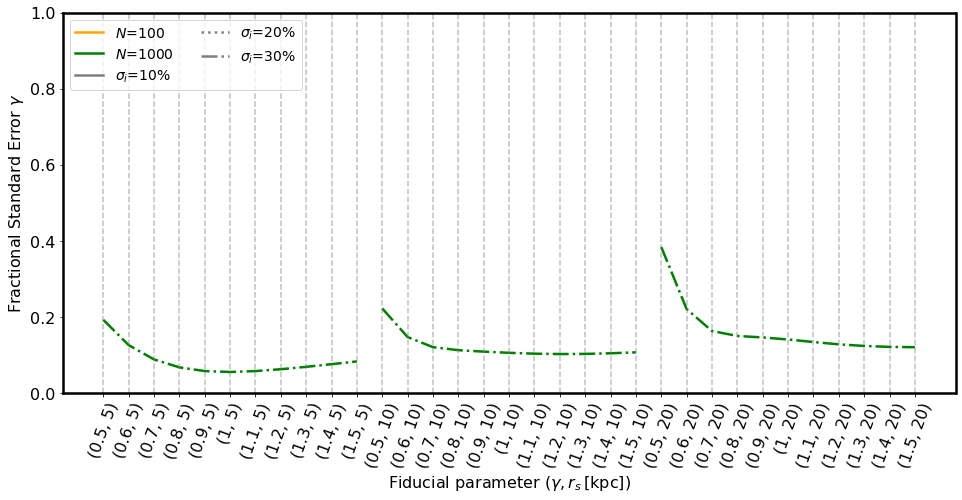

In [87]:
rc('font', family='times new roman', size=16.)

nBDs  = 100
sigma = 0.1

gamma = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
rs    = [5, 10, 20]

x_axis = np.arange(0, 33)

from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, figsize=(16, 7))

path = "/home/mariacst/exoplanets/results/power_law/older_BD/v30/"
pe = "ML"; ex = "baseline_NL_olderBD_v30"

#plot_FSE_pe(path, ex, 10, 0.1, pe, fig, ax, color="blue", ls="-")
#plot_FSE_pe(path, ex, 10, 0.2, pe, fig, ax, color="blue", ls=":")
#plot_FSE_pe(path, ex, 10, 0.3, pe, fig, ax, color="blue", ls="-.")
#plot_FSE_pe(path, ex, 100, 0.1, pe, fig, ax, color="orange", ls="-")
#plot_FSE_pe(path, ex, 100, 0.2, pe, fig, ax, color="orange", ls=":")
#plot_FSE_pe(path, ex, 100, 0.3, pe, fig, ax, color="orange", ls="-.")
#plot_FSE_pe(path, ex, 1000, 0.1, pe, fig, ax, color="green", ls="-")
#plot_FSE_pe(path, ex, 1000, 0.2, pe, fig, ax, color="green", ls=":")
plot_FSE_pe(path, ex, 1000, 0.3, pe, fig, ax, color="green", ls="-.")


ax.set_xticks(x_axis) 
ax.set_xticklabels(['(0.5, 5)', '(0.6, 5)', '(0.7, 5)', '(0.8, 5)', '(0.9, 5)', '(1, 5)', '(1.1, 5)', '(1.2, 5)', '(1.3, 5)', '(1.4, 5)', '(1.5, 5)',
                    '(0.5, 10)', '(0.6, 10)', '(0.7, 10)', '(0.8, 10)', '(0.9, 10)', '(1, 10)', '(1.1, 10)', '(1.2, 10)', '(1.3, 10)', '(1.4, 10)', '(1.5, 10)',
                    '(0.5, 20)', '(0.6, 20)', '(0.7, 20)', '(0.8, 20)', '(0.9, 20)', '(1, 20)', '(1.1, 20)', '(1.2, 20)', '(1.3, 20)', '(1.4, 20)', 
                    '(1.5, 20)'], rotation=70)
ax.set_ylim(0., 1.)
ax.axhline(1., color="k", ls=":")
ax.set_ylabel("Fractional Standard Error $\gamma$"); ax.set_xlabel(r"Fiducial parameter $(\gamma, r_s{\,\rm [kpc]})$")
for x in x_axis:
    ax.axvline(x, ls="--", color="grey", alpha=0.5)
    
legend_elements = [Line2D([0], [0], color='orange', lw=2.5, label='$N$=100'),
                   Line2D([0], [0], color='green', lw=2.5, label='$N$=1000'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle="-", label='$\sigma_i$=10%'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle=":", label='$\sigma_i$=20%'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle="-.", label='$\sigma_i$=30%')]

ax.legend(handles=legend_elements, ncol=2, loc='upper left', fontsize=14)
#fig.savefig("FSE_T650_NL_gNFW_longerPriorG_ML_visu3.png", transparent=True, bbox_inches="tight")

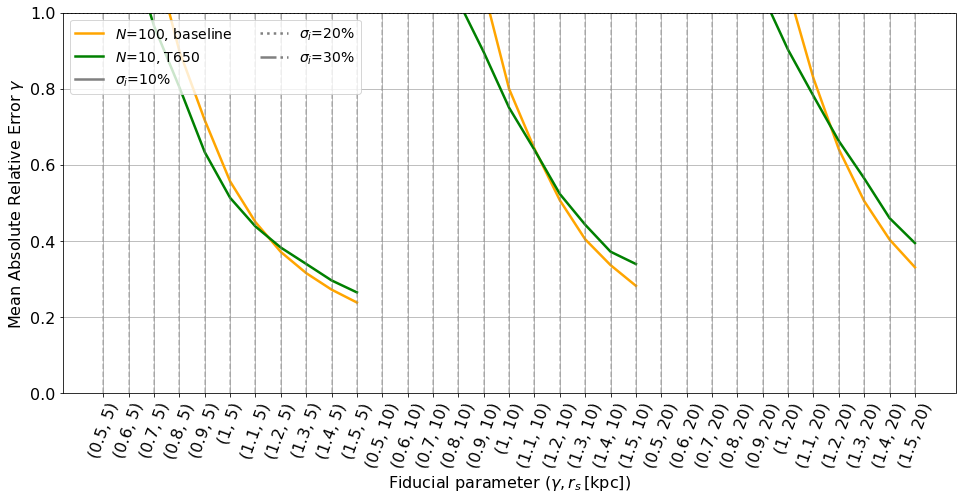

In [54]:
def plot_MARE_pe(path, ex, n, s, pe="ML", fig=None, ax=None, color=None, ls=None):

    if not fig:
        fig, ax = plt.subplots(1, 1, figsize=(11, 5)) 
    #ax.set_title(pe)
    x=0
    if color is None:
        if n<200:
            color="red"
        else:
            color="blue"
    i = 0
    for _rs in rs:
        cove = []; x = [];
        for _g in gamma:
            data = np.genfromtxt(path + "statistics_" + ex +           
                   ("_N%i_sigma%.1f_gamma%.1frs%.1f"%(n, s, _g, _rs)), unpack=True) 
 
            if pe=="ML":                                                       
                _pe = data[9]#[L:N]
                #print(len(_pe), L, N)
            else:     
                sys.exit("Interval not implemented!") 
                
            rank = len(_pe)
            #print(rank)
            
            cove.append(1/rank*np.sum(np.abs(_pe - _g)/_g))
            x.append(i); i+=1
        #print(cove)                            
        ax.plot(x, cove, color=color, ls=ls, lw=2.5)#, label="N=%i"%n)
    return fig, ax




path = "/home/mariacst/exoplanets/results/power_law/older_BD/"

#nBDs = 1000
#sigma = 0.1

gamma = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
rs    = [5, 10, 20]

x_axis = np.arange(0, 33)

from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, figsize=(16, 7))

pe = "ML"; ex="baseline_NL_olderBD"

plot_MARE_pe(path, ex, 10, 0.1, pe, fig, ax, color="orange", ls="-")

#plot_MARE_pe(path, ex, 100, 0.2, 0, 100, pe, fig, ax, color="blue", ls=":")
#plot_MARE_pe(path, ex, 100, 0.3, 0, 100, pe, fig, ax, color="purple", ls=":")

#plot_MARE_pe(path, ex, 100, 0.1, 0, 200, pe, fig, ax, color="orange", ls=":")
#plot_MARE_pe(path, ex, 1000, 0.1, 0, 200, pe, fig, ax, color="orange", ls="--")
#plot_MARE_pe(path, ex, 10, 0.3, pe, fig, ax, color="orange", ls="-.")

ex="T650_NL_olderBD"
plot_MARE_pe(path, ex, 10, 0.1, pe, fig, ax, color="green", ls="-")
#plot_MARE_pe(path, ex, 10, 0.1, 0, 200, pe, fig, ax, color="green", ls=":")
#plot_MARE_pe(path, ex, 10, 0.2, pe, fig, ax, color="green", ls=":")
#plot_MARE_pe(path, ex, 10, 0.3, pe, fig, ax, color="green", ls="-.")


ax.set_xticks(x_axis) 
ax.set_xticklabels(['(0.5, 5)', '(0.6, 5)', '(0.7, 5)', '(0.8, 5)', '(0.9, 5)', '(1, 5)', '(1.1, 5)', '(1.2, 5)', '(1.3, 5)', '(1.4, 5)', '(1.5, 5)',
                    '(0.5, 10)', '(0.6, 10)', '(0.7, 10)', '(0.8, 10)', '(0.9, 10)', '(1, 10)', '(1.1, 10)', '(1.2, 10)', '(1.3, 10)', '(1.4, 10)', '(1.5, 10)',
                    '(0.5, 20)', '(0.6, 20)', '(0.7, 20)', '(0.8, 20)', '(0.9, 20)', '(1, 20)', '(1.1, 20)', '(1.2, 20)', '(1.3, 20)', '(1.4, 20)', 
                    '(1.5, 20)'], rotation=70)
ax.set_ylim(0., 1.)
ax.axhline(1., color="k", ls=":")
ax.set_ylabel("Mean Absolute Relative Error $\gamma$"); ax.set_xlabel(r"Fiducial parameter $(\gamma, r_s{\,\rm [kpc]})$")
for x in x_axis:
    ax.axvline(x, ls="--", color="grey", alpha=0.5)
    
legend_elements = [Line2D([0], [0], color='orange', lw=2.5, label='$N$=100, baseline'),
                   Line2D([0], [0], color='green', lw=2.5, label='$N$=10, T650'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle="-", label='$\sigma_i$=10%'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle=":", label='$\sigma_i$=20%'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle="-.", label='$\sigma_i$=30%')]

ax.grid(which="both")
ax.legend(handles=legend_elements, ncol=2, loc='upper left', fontsize=14)
#fig.savefig("MARE_baseline_NL_youngerVSolder_logML_visu2.png", transparent=True, bbox_inches="tight")

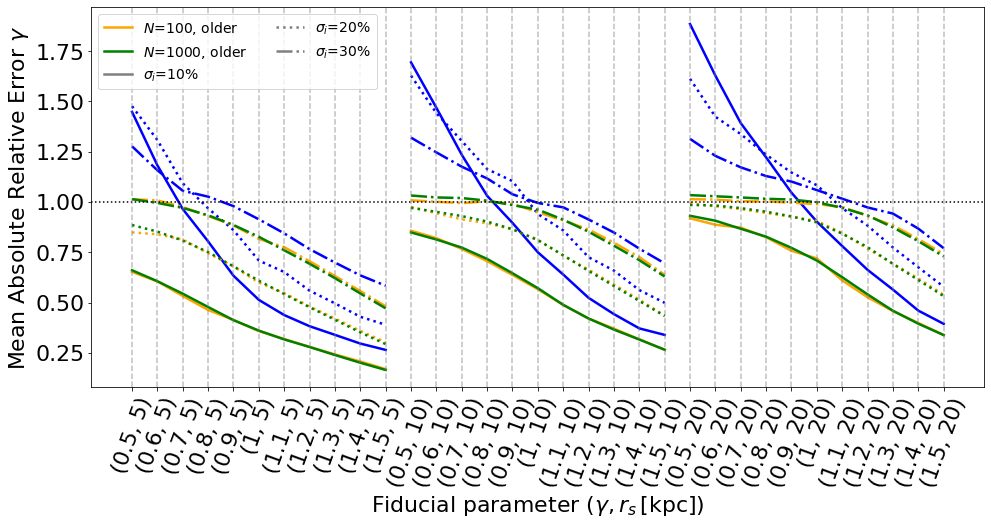

In [45]:
fig, ax = plt.subplots(1, 1, figsize=(16, 7))

pe = "ML"; ex="T650_NL_olderBD"

plot_MARE_pe(path, ex, 10, 0.1, pe, fig, ax, color="blue", ls="-")
plot_MARE_pe(path, ex, 10, 0.2, pe, fig, ax, color="blue", ls=":")
plot_MARE_pe(path, ex, 10, 0.3, pe, fig, ax, color="blue", ls="-.")

plot_MARE_pe(path, ex, 100, 0.1, pe, fig, ax, color="orange", ls="-")
plot_MARE_pe(path, ex, 100, 0.2, pe, fig, ax, color="orange", ls=":")
plot_MARE_pe(path, ex, 100, 0.3, pe, fig, ax, color="orange", ls="-.")
plot_MARE_pe(path, ex, 1000, 0.1, pe, fig, ax, color="green", ls="-")
plot_MARE_pe(path, ex, 1000, 0.2, pe, fig, ax, color="green", ls=":")
plot_MARE_pe(path, ex, 1000, 0.3, pe, fig, ax, color="green", ls="-.")


ax.set_xticks(x_axis) 
ax.set_xticklabels(['(0.5, 5)', '(0.6, 5)', '(0.7, 5)', '(0.8, 5)', '(0.9, 5)', '(1, 5)', '(1.1, 5)', '(1.2, 5)', '(1.3, 5)', '(1.4, 5)', '(1.5, 5)',
                    '(0.5, 10)', '(0.6, 10)', '(0.7, 10)', '(0.8, 10)', '(0.9, 10)', '(1, 10)', '(1.1, 10)', '(1.2, 10)', '(1.3, 10)', '(1.4, 10)', '(1.5, 10)',
                    '(0.5, 20)', '(0.6, 20)', '(0.7, 20)', '(0.8, 20)', '(0.9, 20)', '(1, 20)', '(1.1, 20)', '(1.2, 20)', '(1.3, 20)', '(1.4, 20)', 
                    '(1.5, 20)'], rotation=70)
#ax.set_ylim(0., 0.2)
ax.axhline(1., color="k", ls=":")
ax.set_ylabel("Mean Absolute Relative Error $\gamma$"); ax.set_xlabel(r"Fiducial parameter $(\gamma, r_s{\,\rm [kpc]})$")
for x in x_axis:
    ax.axvline(x, ls="--", color="grey", alpha=0.5)
    
legend_elements = [Line2D([0], [0], color='orange', lw=2.5, label='$N$=100, older'),
                   Line2D([0], [0], color='green', lw=2.5, label='$N$=1000, older'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle="-", label='$\sigma_i$=10%'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle=":", label='$\sigma_i$=20%'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle="-.", label='$\sigma_i$=30%')]

ax.legend(handles=legend_elements, ncol=2, loc='upper left', fontsize=14)

In [4]:
def plot_MARE_pe(path, ex, n, s, pe="ML", fig=None, ax=None, color=None, ls=None, label=None):

    if not fig:
        fig, ax = plt.subplots(1, 1, figsize=(11, 5)) 
    #ax.set_title(pe)
    x=0
    if color is None:
        if n<200:
            color="red"
        else:
            color="blue"
    i = 0
    for _rs in rs:
        cove = []; x = [];
        for _g in gamma:
            data = np.genfromtxt(path + "statistics_" + ex +           
                   ("_N%i_sigma%.1f_gamma%.1frs%.1f"%(n, s, _g, _rs)), unpack=True) 
 
            if pe=="ML":                                                       
                _pe = data[9]
            else:     
                sys.exit("Interval not implemented!") 
                
            rank = len(_pe)
            
            cove.append(1/rank*np.sum(np.abs(_pe - _g)/_g))
            x.append(i); i+=1
        #print(cove)                            
        ax.plot(x, cove, color=color, ls=ls, lw=2.5, label=label)#, label="N=%i"%n)
    return fig, ax

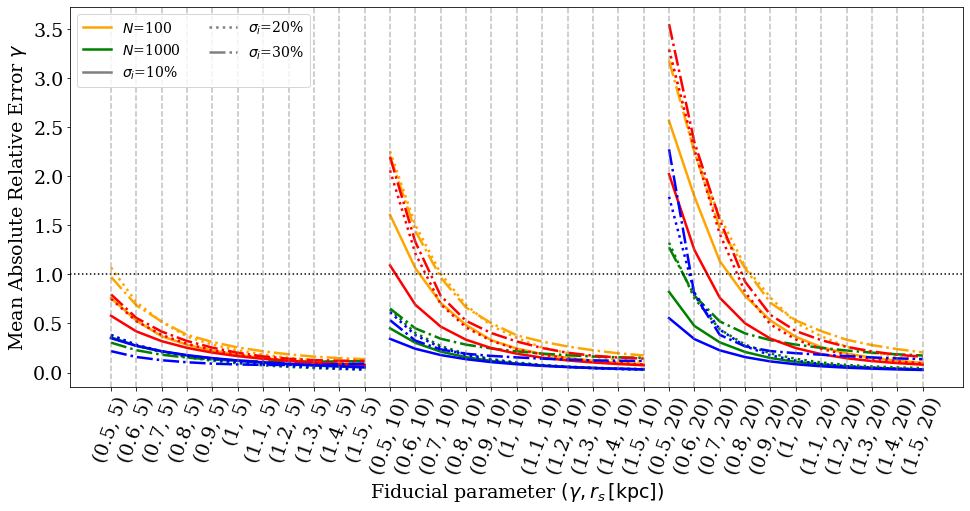

In [4]:
gamma = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
rs    = [5, 10, 20]

x_axis = np.arange(0, 33)

from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, figsize=(16, 7))

pe = "ML"; ex="baseline_NL_log"

plot_MARE_pe(path, ex, 100, 0.1, pe, fig, ax, color="orange", ls="-")
plot_MARE_pe(path, ex, 100, 0.2, pe, fig, ax, color="orange", ls=":")
plot_MARE_pe(path, ex, 100, 0.3, pe, fig, ax, color="orange", ls="-.")
plot_MARE_pe(path, ex, 1000, 0.1, pe, fig, ax, color="green", ls="-")
plot_MARE_pe(path, ex, 1000, 0.2, pe, fig, ax, color="green", ls=":")
plot_MARE_pe(path, ex, 1000, 0.3, pe, fig, ax, color="green", ls="-.")

path = "/home/mariacst/exoplanets/results/power_law/older_BD/"
pe = "ML"; ex="baseline_NL_olderBD"

plot_MARE_pe(path, ex, 100, 0.1, pe, fig, ax, color="red", ls="-", label="olderBD")
plot_MARE_pe(path, ex, 100, 0.2, pe, fig, ax, color="red", ls=":")
plot_MARE_pe(path, ex, 100, 0.3, pe, fig, ax, color="red", ls="-.")
plot_MARE_pe(path, ex, 1000, 0.1, pe, fig, ax, color="b", ls="-", label="olderBD")
plot_MARE_pe(path, ex, 1000, 0.2, pe, fig, ax, color="b", ls=":")
plot_MARE_pe(path, ex, 1000, 0.3, pe, fig, ax, color="b", ls="-.")


ax.set_xticks(x_axis) 
ax.set_xticklabels(['(0.5, 5)', '(0.6, 5)', '(0.7, 5)', '(0.8, 5)', '(0.9, 5)', '(1, 5)', '(1.1, 5)', '(1.2, 5)', '(1.3, 5)', '(1.4, 5)', '(1.5, 5)',
                    '(0.5, 10)', '(0.6, 10)', '(0.7, 10)', '(0.8, 10)', '(0.9, 10)', '(1, 10)', '(1.1, 10)', '(1.2, 10)', '(1.3, 10)', '(1.4, 10)', '(1.5, 10)',
                    '(0.5, 20)', '(0.6, 20)', '(0.7, 20)', '(0.8, 20)', '(0.9, 20)', '(1, 20)', '(1.1, 20)', '(1.2, 20)', '(1.3, 20)', '(1.4, 20)', 
                    '(1.5, 20)'], rotation=70)
#ax.set_ylim(0., 1.)
ax.axhline(1., color="k", ls=":")
ax.set_ylabel("Mean Absolute Relative Error $\gamma$"); ax.set_xlabel(r"Fiducial parameter $(\gamma, r_s{\,\rm [kpc]})$")
for x in x_axis:
    ax.axvline(x, ls="--", color="grey", alpha=0.5)
    
legend_elements = [Line2D([0], [0], color='orange', lw=2.5, label='$N$=100'),
                   Line2D([0], [0], color='green', lw=2.5, label='$N$=1000'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle="-", label='$\sigma_i$=10%'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle=":", label='$\sigma_i$=20%'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle="-.", label='$\sigma_i$=30%')]

ax.legend(handles=legend_elements, ncol=2, loc='upper left', fontsize=14)
fig.savefig("MARE_" + ex + "_visu2.png", transparent=True, bbox_inches="tight")

(0.0, 0.5)

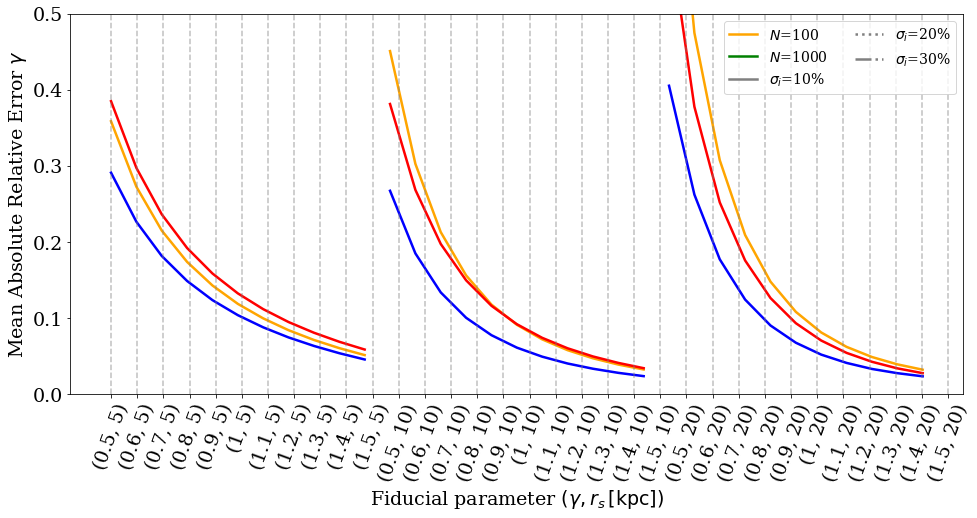

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(16, 7))

pe = "ML"; 

gamma = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
rs    = [5, 10, 20]

path = "/home/mariacst/exoplanets/results/power_law/"

ex="baseline_NL_log"
plot_MARE_pe(path, ex, 1000, 0.1, pe, fig, ax, color="orange", ls="-")
path = "/home/mariacst/exoplanets/results/power_law/older_BD/"
ex="baseline_NL_olderBD_Emass"
plot_MARE_pe(path, ex, 1000, 0.1, pe, fig, ax, color="red", ls="-")
ex="baseline_NL_olderBD_Eage"
plot_MARE_pe(path, ex, 1000, 0.1, pe, fig, ax, color="blue", ls="-")
ex="baseline_NL_olderBD_Er"
#plot_MARE_pe(path, ex, 1000, 0.3, pe, fig, ax, color="purple", ls="-")

x_axis = np.linspace(0, 33, 33)
ax.set_xticks(x_axis) 
ax.set_xticklabels(['(0.5, 5)', '(0.6, 5)', '(0.7, 5)', '(0.8, 5)', '(0.9, 5)', '(1, 5)', '(1.1, 5)', 
                    '(1.2, 5)', '(1.3, 5)', '(1.4, 5)', '(1.5, 5)',
                    '(0.5, 10)', '(0.6, 10)', '(0.7, 10)', '(0.8, 10)', '(0.9, 10)', '(1, 10)', '(1.1, 10)', '(1.2, 10)', '(1.3, 10)', '(1.4, 10)', '(1.5, 10)',
                    '(0.5, 20)', '(0.6, 20)', '(0.7, 20)', '(0.8, 20)', '(0.9, 20)', '(1, 20)', '(1.1, 20)', '(1.2, 20)', '(1.3, 20)', '(1.4, 20)', 
                    '(1.5, 20)'], 
                    rotation=70)
#ax.set_ylim(0., 1.)
#ax.axhline(1., color="k", ls=":")
ax.set_ylabel("Mean Absolute Relative Error $\gamma$"); ax.set_xlabel(r"Fiducial parameter $(\gamma, r_s{\,\rm [kpc]})$")
for x in x_axis:
    ax.axvline(x, ls="--", color="grey", alpha=0.5)
    
legend_elements = [Line2D([0], [0], color='orange', lw=2.5, label='$N$=100'),
                   Line2D([0], [0], color='green', lw=2.5, label='$N$=1000'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle="-", label='$\sigma_i$=10%'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle=":", label='$\sigma_i$=20%'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle="-.", label='$\sigma_i$=30%')]

ax.legend(handles=legend_elements, ncol=2, loc='upper right', fontsize=14)
ax.set_ylim(0, 0.5)

In [2]:
from astropy.constants import M_jup, M_sun, R_jup
sys.path.append("/home/mariacst/exoplanets/running/power_law/baseline_NL/")
from _utils import heat, temperature_withDM 

def IMF_sampling(alpha, size, Mmin=14, Mmax=55):                                
    """                                                                         
    Sampling from power-law distribution                                        
    """                                                                         
    y = np.random.uniform(0, 1, size=size)                                      
    return ((Mmax**(alpha+1) - Mmin**(alpha+1))*y + Mmin**(alpha+1))**(1./(alpha+1))


def rho_bulge(r, phi, theta, R0=8.178, x0=0.899, y0=0.386, z0=0.250,            
              alpha=0.415):                                                     
    """                                                                         
    Density profile for Stanek + '97 (E2) bulge [arbitrary units]               
    (all spatial coordiantes are given in kpc)                                  
    """                                                                         
    x0 = x0*R0/8. # rescale to adopted R0 value                                 
    y0 = y0*R0/8.                                                               
    # return                                                                    
    return (np.exp(-np.sqrt(np.sin(theta)**2*((np.cos(phi+alpha)/x0)**2 +       
                            (np.sin(phi+alpha)/y0)**2) +                        
                            (np.cos(theta)/z0)**2)*r))                          
def rho_disc(r, theta, R0=8.178, Rd=2.15, zh=0.40):                             
    """                                                                         
    Density profile for Bovy and Rix disc [arbitrary units]                     
    (all spatial coordiantes are given in kpc)                                  
    """                                                                         
    Rd = Rd*R0/8. # rescale to adopted R0 value                                 
    # return                                                                    
    return np.exp(-r*np.sin(theta)/Rd)*np.exp(-r*np.cos(theta)/zh)              
                                                                                
def rho(r, phi, theta, R0=8.178):                                               
    """                                                                         
    Density profile [arbitrary units]                                           
    """                                                                         
    # continuity condition at r = 1 kpc                                         
    C    = rho_disc(1., theta, R0)/rho_bulge(1., phi, theta, R0)                
    _rho = C*rho_bulge(r, phi, theta, R0)                                       
    # return                                                                    
    return (np.heaviside(1.-r, 1.)*_rho +                                       
            np.heaviside(r-1., 0.)*rho_disc(r, theta, R0))                      
                                                                                
def spatial_sampling(nBDs, phi=0., theta=np.pi/2., R0=8.178):                   
    """                                                                         
    Sampling nBDs points from density profile rho using Von Neumann             
    acceptance-rejection technique                                              
    """                                                                         
    ymin = 0.1; ymax = 1.0#R0                                                   
    #print("maximimum observed GC distance = ", ymax)                           
    umin = np.min([rho(ymin, phi, theta), rho(1., phi, theta),                  
                   rho(R0, phi, theta)])                                        
    umax = np.max([rho(ymin, phi, theta), rho(1., phi, theta),                  
                   rho(R0, phi, theta)])                                        
    i = 0                                                                       
    r = np.ones(nBDs)*100                                                       
    while i<nBDs:                                                               
        yi = np.random.uniform(ymin, ymax)                                      
        ui = np.random.uniform(umin, umax)                                      
        if ui < rho(yi, phi, theta, R0):                                        
            r[i] = yi                                                           
            i+=1                                                                
    # return                                                                    
    return r

def mock_population_all(N, relT, relM, relRobs, relA,                           
                        f_true, gamma_true, rs_true, rho0_true=0.42,            
                        Tmin=0., v=None):                                       
    """                                                                         
    Generate N observed exoplanets                                              
                                                                                
    Assumptions                                                                 
    -----------                                                                 
    1) N observed exoplanets distributed according to E2 bulge + BR disc        
    2) (All) exoplanets radius = Rjup                                           
    3) BD evolution model taken from ATMO 2020                                  
    4) BDs have masses chosen between 14-55 Mjup assuming power-law IMF and     
       unifrom age distribution between 1-10 Gyr                                
    5) Tobs has relative uncertainty rel_unc_Tobs                               
    6) Estimated masses have an uncertainty of rel_mass                         
    """                                                                         
    #np.random.seed(42)                                                            
    #print(Tmin)                                                                   
    _N = int(8.5*N)                                                                
    # galactocentric radius of simulated exoplanets                                
    r_obs = spatial_sampling(_N)                                                   
    # Age                                                                          
    ages = np.random.uniform(1., 10., _N) # [yr] / [1-10 Gyr]                      
    # Mass                                                                         
    mass = IMF_sampling(-0.6, _N, Mmin=6, Mmax=75) # [Mjup]                        
    mass = mass*M_jup.value/M_sun.value # [Msun]                                   
    # load theoretical BD cooling model - ATMO 2020                                
    path =  "/home/mariacst/exoplanets/running/data/"                              
    data = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)           
    points = np.transpose(data[0:2, :])                                            
    values = data[2]                                                               
    xi = np.transpose(np.asarray([ages, mass]))                                    
                                                                                   
    Teff     = griddata(points, values, xi)                                        
    # Observed velocity (internal heating + DM)                                    
    Tobs = temperature_withDM(r_obs, Teff, R=R_jup.value,                          
                           M=mass*M_sun.value,                                     
                           f=f_true, p=[gamma_true, rs_true, rho0_true],           
                           v=v)                                                    
    # add Gaussian noise                                                           
    Tobs_wn = Tobs + np.random.normal(loc=0, scale=(relT*Tobs), size=_N)           
    mass_wn = mass + np.random.normal(loc=0, scale=(relM*mass), size=_N)           
    robs_wn = r_obs + np.random.normal(loc=0, scale=(relRobs*r_obs), size=_N)   
    ages_wn = ages + np.random.normal(loc=0, scale=(relA*ages), size=_N)           
    # select only those objects with masses between 14 and 55 Mjup and T > Tmin 
    pos  = np.where((mass_wn > 0.015) & (mass_wn < 0.051) & # 16 - 53 Mjup!        
                    (Tobs_wn > Tmin) &                                             
                    (robs_wn > 0.1) & (robs_wn < 1.) &                             
                    (ages_wn > 1.002) & (ages_wn < 9.998))                         
    #print("Tmin = ", Tmin, len(pos[0]))                                           
    if len(pos[0]) < N:                                                            
        sys.exit("Less objects than required!")                                    
    #return                                                                        
    return (mass_wn[pos][:N], mass[pos][:N]) 

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


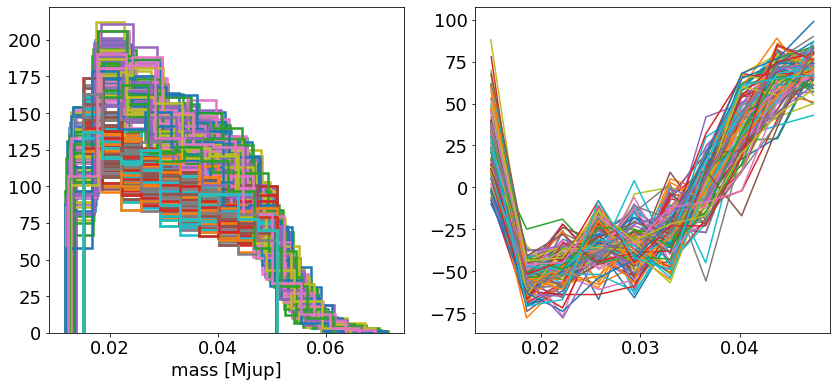

In [26]:
N=1000

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

diff = []; diff_wn = []
for i in range(100):
    print(i)
    sigma=0.1
    np.random.seed(i)
    mass_wn, mass = mock_population_all(N, 0.1, sigma, sigma, sigma, 1., 1.5, 5.)
    counts1, bins, _ = ax[0].hist(mass, histtype="step", lw=2.5, label=r"$\sigma=$0.1");
    counts1_wn, bins_wn, _ = ax[0].hist(mass_wn, histtype="step", lw=2.5, label=r"$\sigma=$0.1");
                    
    sigma=0.
    np.random.seed(i)
    mass_wn, mass = mock_population_all(N, 0.1, sigma, sigma, sigma, 1., 1.5, 5.)
    
    counts2, bins, _ = ax[0].hist(mass, histtype="step", lw=2.5, label=r"$\sigma=$0.2")
    counts2_wn, bins_wn, _ = ax[0].hist(mass_wn, histtype="step", lw=2.5, label=r"$\sigma=$0.2")
    ax[0].set_xlabel("mass [Mjup]"); #ax[0].legend()
    diff.append(counts2-counts1)
    diff_wn.append(counts2_wn-counts1_wn)
    ax[1].plot(bins[:-1], counts2-counts1)

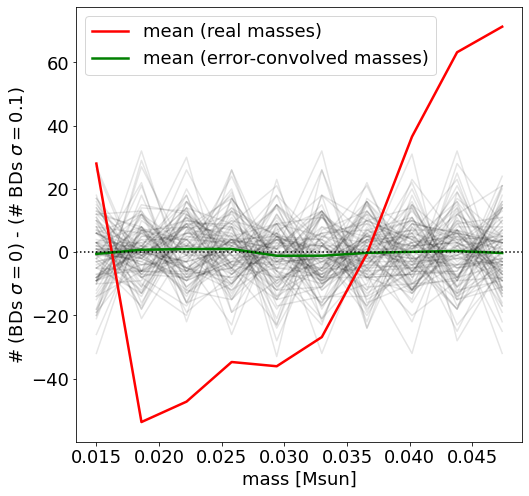

In [27]:
diff = np.array(diff); diff_wn = np.array(diff_wn)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
for i in range(100):
    #ax.plot(bins[:-1], diff[i], color="k", alpha=0.1)
    ax.plot(bins_wn[:-1], diff_wn[i], color="k", alpha=0.1)
ax.plot(bins[:-1], np.mean(diff, axis=0), color="r", lw=2.5, label="mean (real masses)")
ax.plot(bins_wn[:-1], np.mean(diff_wn, axis=0), color="green", lw=2.5, label="mean (error-convolved masses)")
ax.axhline(0., color="k", ls=":"); 
ax.set_ylabel(r"(# BDs $\sigma=0.$) - (# BDs $\sigma=0.1$)")
ax.set_xlabel("mass [Msun]"); ax.legend(); 
fig.savefig("observational_bias_gamma1.5rs5_sigma0.1_sigma0.png", bbox_inches="tight")

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


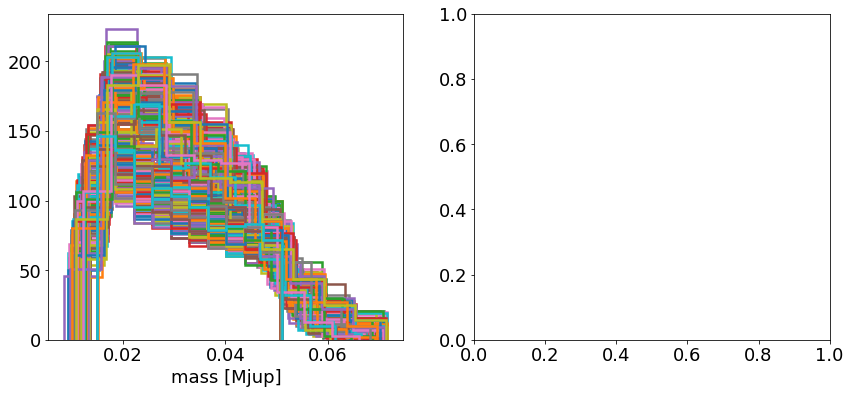

In [20]:
N=1000

fig, ax = plt.subplots(1, 2, figsize=(14, 6))


diff1 = []; diff1_wn = []; diff0 = []; diff0_wn = []; diff2 = []; diff2_wn = []

for i in range(100):
    print(i)
    
    sigma=0.
    np.random.seed(i)
    mass_wn, mass = mock_population_all(N, 0., sigma, sigma, sigma, 1., 1.5, 5.)
    counts, bins, _ = ax[0].hist(mass, histtype="step", lw=2.5, label=r"$\sigma=$0.2")
    
    sigma=0.
    np.random.seed(i)
    mass_wn, mass = mock_population_all(N, 0.1, sigma, sigma, sigma, 1., 1.5, 5.)
    counts0, bins0, _ = ax[0].hist(mass, histtype="step", lw=2.5, label=r"$\sigma=$0.2")
    counts0_wn, bins0_wn, _ = ax[0].hist(mass_wn, histtype="step", lw=2.5, label=r"$\sigma=$0.2")
        
    sigma=0.1
    np.random.seed(i)
    mass_wn, mass = mock_population_all(N, 0.1, sigma, sigma, sigma, 1., 1.5, 5.)
    counts1, bins1, _ = ax[0].hist(mass, histtype="step", lw=2.5, label=r"$\sigma=$0.1");
    counts1_wn, bins1_wn, _ = ax[0].hist(mass_wn, histtype="step", lw=2.5, label=r"$\sigma=$0.1");
                    
        
    sigma=0.2
    np.random.seed(i)
    mass_wn, mass = mock_population_all(N, 0.1, sigma, sigma, sigma, 1., 1.5, 5.)
    counts2, bins2, _ = ax[0].hist(mass, histtype="step", lw=2.5, label=r"$\sigma=$0.2")
    counts2_wn, bins2_wn, _ = ax[0].hist(mass_wn, histtype="step", lw=2.5, label=r"$\sigma=$0.2")
    
    
    ax[0].set_xlabel("mass [Mjup]"); #ax[0].legend()
    diff1.append(counts1-counts); diff1_wn.append(counts1_wn-counts)
    diff0.append(counts0-counts); diff0_wn.append(counts0_wn-counts)
    diff2.append(counts2-counts); diff2_wn.append(counts2_wn-counts)

No handles with labels found to put in legend.


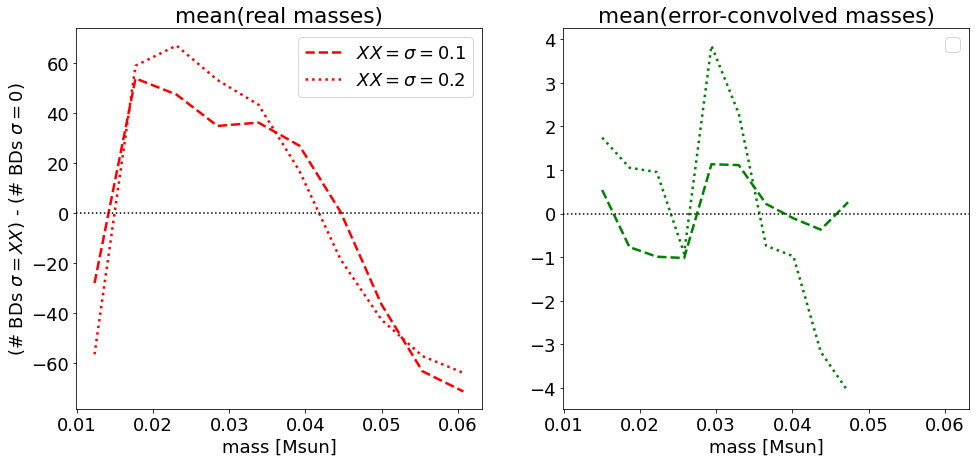

In [25]:
#diff0 = np.array(diff0); diff0_wn = np.array(diff0_wn)
#diff1 = np.array(diff1); diff1_wn = np.array(diff1_wn)

fig, ax = plt.subplots(1, 2, figsize=(16, 7), sharex=True)
#ax[0].plot(bins0[:-1], np.mean(diff0, axis=0), color="r", lw=2.5)
#ax[1].plot(bins0_wn[:-1], np.mean(diff0_wn, axis=0), color="green", lw=2.5, label="mean (error-convolved masses)")

ax[0].plot(bins1[:-1], np.mean(diff1, axis=0), color="r", ls="--", lw=2.5, label=r"$XX=\sigma=0.1$")
ax[1].plot(bins1_wn[:-1], np.mean(diff1_wn, axis=0), color="green", ls="--", lw=2.5)

ax[0].plot(bins1[:-1], np.mean(diff2, axis=0), color="r", ls=":", lw=2.5, label=r"$XX=\sigma=0.2$")
ax[1].plot(bins1_wn[:-1], np.mean(diff2_wn, axis=0), color="green", ls=":", lw=2.5)

ax[0].axhline(0., color="k", ls=":"); ax[1].axhline(0., color="k", ls=":"); 
ax[0].set_ylabel(r"(# BDs $\sigma=XX$) - (# BDs $\sigma=0.$)")
ax[0].set_xlabel("mass [Msun]"); ax[0].legend(); ax[1].set_xlabel("mass [Msun]");
ax[1].legend(); ax[0].set_title("mean(real masses)")
ax[1].set_title("mean(error-convolved masses)")
fig.savefig("observational_bias_gamma1.5rs5.png", bbox_inches="tight")

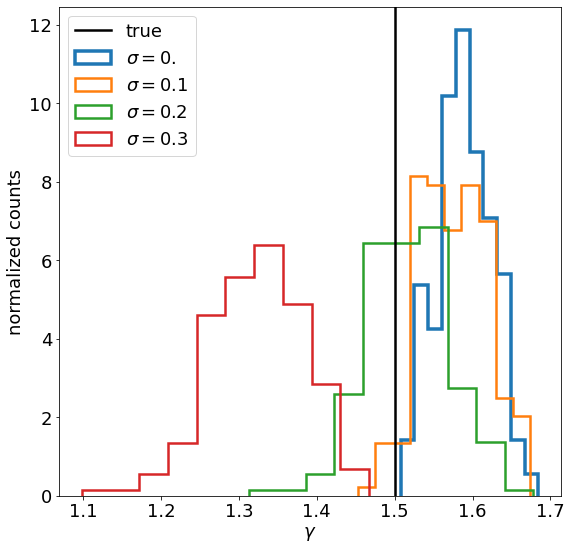

In [20]:
path = "/home/mariacst/exoplanets/results/power_law/"
ex="baseline_NL"
_g = 1.5; _rs=5.; n=1000

s=0.
data = np.genfromtxt(path + "statistics_" + ex + ("_N%i_sigma%.1f_gamma%.1frs%.1f"%(n, s, _g, _rs)),
                     unpack=True) 
pe0 = data[9]

ex="baseline_NL_log"
s=0.1
data = np.genfromtxt(path + "statistics_" + ex + ("_N%i_sigma%.1f_gamma%.1frs%.1f"%(n, s, _g, _rs)),
                     unpack=True) 
pe1 = data[9]

s=0.2
data = np.genfromtxt(path + "statistics_" + ex + ("_N%i_sigma%.1f_gamma%.1frs%.1f"%(n, s, _g, _rs)),
                     unpack=True) 
pe2 = data[9]

s=0.3
data = np.genfromtxt(path + "statistics_" + ex + ("_N%i_sigma%.1f_gamma%.1frs%.1f"%(n, s, _g, _rs)),
                     unpack=True) 
pe3 = data[9]

fig, ax = plt.subplots(1, 1, figsize=(9, 9))
ax.hist(pe0, histtype="step", label="$\sigma=$0.", lw=3.5, density=True)
ax.hist(pe1, histtype="step", label="$\sigma=$0.1", lw=2.5, density=True); 
ax.hist(pe2, histtype="step", label="$\sigma=$0.2", lw=2.5, density=True)
ax.hist(pe3, histtype="step", label="$\sigma=$0.3", lw=2.5, density=True)

ax.axvline(_g, color="k", label="true", lw=2.5); ax.legend(loc="upper left")
ax.set_ylabel("normalized counts"); ax.set_xlabel(r"$\gamma$")
fig.savefig("observational_bias_FSE_distribution.png", bbox_inches="tight")

findfont: Font family ['times new roman'] not found. Falling back to DejaVu Sans.


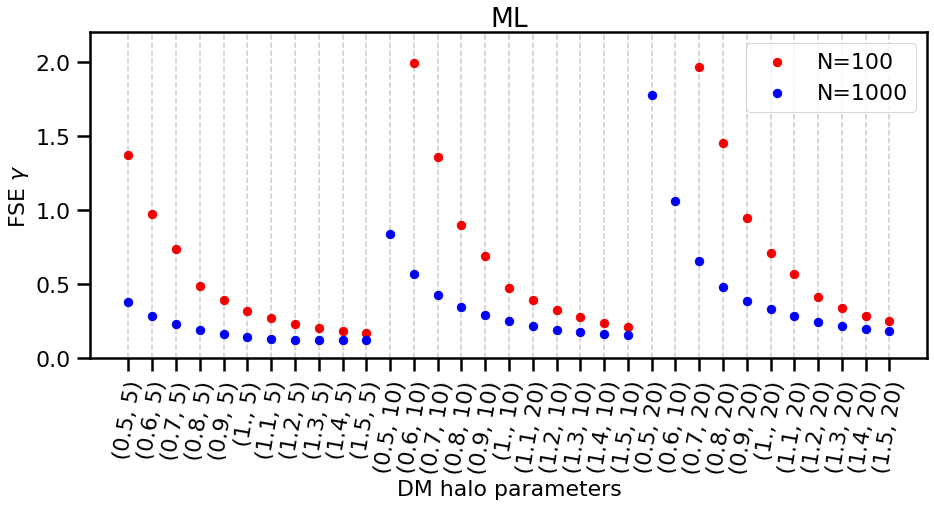

In [41]:
import imp
import utils_plots
imp.reload(utils_plots)

from utils_plots import FSE_f_gamma_rs


#IMPORTANT CHANGE UTILS_PLOTS INPUT STAT FILE!!!

path = "/home/mariacst/exoplanets/results/power_law/"

nBDs = [100, 1000]
sigma = 0.3


gamma = [0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1, 1.2, 1.3, 1.4, 1.5]
rs    = [5, 10, 20]
x     = np.linspace(0, 1, 33)

PE     = ["ML"]#, "median", "mode2", "ML"]
color  = ["red", "blue"]
marker = ["o", "s", "<", "d"]

j=0
for pe in PE:   
    fig, ax = plt.subplots(1, 1, figsize=(15, 6))    
    i=0
    for N in nBDs:
        xi, yi, zi = FSE_f_gamma_rs(path, N, sigma, "baseline_NL_log", PE=pe)    
        ax.scatter(x, np.ravel(zi), color=color[i], marker="o", label="N=%i"%N, s=70.)
        
        #xi, yi, zi = FSE_f_gamma_rs(path, N, sigma, "baseline_log", PE=pe)    
        #ax.scatter(x, np.ravel(zi), color=color[i], marker="s", s=70.)
        
        i+=1
    j+=1
    
    for axis in ['top','bottom','left','right']:                                    
        ax.spines[axis].set_linewidth(2.5) 
    ax.tick_params(which='major',direction="out",width=2.5,length=13,right=False,top=False,pad=7)
    
    for i in x:
        ax.axvline(i, ls="--", alpha=0.2, color="k")

    ax.legend()
    ax.set_xticks(x)    

    ax.set_xticklabels(['(0.5, 5)', '(0.6, 5)', '(0.7, 5)', '(0.8, 5)', '(0.9, 5)', 
                        '(1., 5)', '(1.1, 5)', '(1.2, 5)', '(1.3, 5)', '(1.4, 5)', '(1.5, 5)',
                       '(0.5, 10)', '(0.6, 10)', '(0.7, 10)', '(0.8, 10)', '(0.9, 10)', 
                        '(1., 10)', '(1.1, 20)', '(1.2, 10)', '(1.3, 10)', '(1.4, 10)', '(1.5, 10)', 
                        '(0.5, 20)', '(0.6, 10)', '(0.7, 20)', '(0.8, 20)', '(0.9, 20)', 
                        '(1., 20)', '(1.1, 20)', '(1.2, 20)', '(1.3, 20)', '(1.4, 20)', '(1.5, 20)', 
                       ], 
                   rotation=80);

    ax.set_ylabel(r"FSE $\gamma$"); ax.set_xlabel("DM halo parameters")
    ax.set_title(pe)
    ax.set_ylim(0., 2.2)
    

#FSE_mean_100  = [0.597, 0.589, np.nan, np.nan, np.nan, np.nan, np.nan, 0.246, 0.208, 0.160, 0.115]
#FSE_mean_1000 = [0.731, 0.661, np.nan, np.nan, np.nan, np.nan, np.nan, 0.289, 0.246, 0.201, 0.154] 

#ax.scatter(x[:len(FSE_mean_100)], FSE_mean_100, color="red", marker="d")
#ax.scatter(x[:len(FSE_mean_1000)], FSE_mean_1000, color="blue", marker="d")

#fig.savefig(ex + "_FSE_gamma.png", bbox_inches="tight")

In [36]:
import utils_plots
import imp
imp.reload(utils_plots)
from utils_plots import grid_coverage

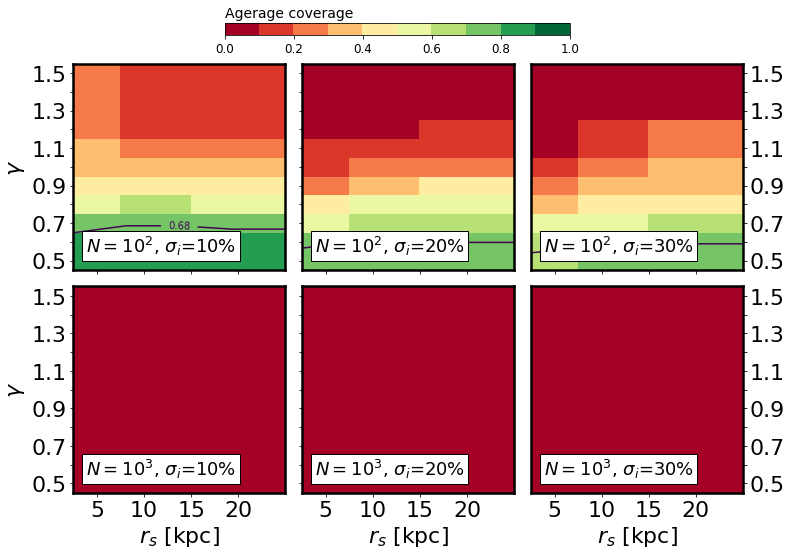

In [50]:
path = "/home/mariacst/exoplanets/results/power_law/"
ex   = "T650_NL_log"

for pe in ["LI"]:
    fig, ax = plt.subplots(2, 3, figsize=(12, 8))
    cs = grid_coverage(path, 100, 0.1,  ex, ax[0, 0], pe, ylabel=True, xlabel=False)
    grid_coverage(path, 1000, 0.1, ex, ax[1, 0], pe, ylabel=True, xlabel=True)
    grid_coverage(path, 100, 0.2,  ex, ax[0, 1], pe, ylabel=False, xlabel=False)
    grid_coverage(path, 1000, 0.2, ex, ax[1, 1], pe, ylabel=False, xlabel=True)
    grid_coverage(path, 100, 0.3,  ex, ax[0, 2], pe, ylabel=False, xlabel=False)
    grid_coverage(path, 1000, 0.3, ex, ax[1, 2], pe, ylabel=False, xlabel=True)

    ax[0, 2].set_yticklabels(['0.5', '', '0.7', '', '0.9', '', '1.1', '', '1.3', '', '1.5'])
    ax[1, 2].set_yticklabels(['0.5', '', '0.7', '', '0.9', '', '1.1', '', '1.3', '', '1.5'])
    ax[0, 2].yaxis.tick_right(); ax[1, 2].yaxis.tick_right()  
    
    fig.subplots_adjust(top=0.87)
    cbar_ax = fig.add_axes([0.3, 0.92, 0.4, 0.02])
    cbar = fig.colorbar(cs, cax=cbar_ax, orientation="horizontal")    
    cbar.ax.tick_params(labelsize=12)
    cbar.ax.set_title(r"Agerage coverage", size=14., loc="left")
    
    fig.subplots_adjust(wspace=0.08, hspace=0.08)
    
    fig.savefig("coverage_" + ex + pe + ".png", transparent=True)

In [57]:
path = "/home/mariacst/exoplanets/results/power_law/sigma/"

nBDs = [100]
sigma = [0.3]

gamma = [0.5, 0.6]#, 0.8,1.2, 1.4, 1.5]
rs    = [5, 20]

PE     = ["mean", "median", "mode", "ML"]
color  = ["red", "blue"]
marker = ["o", "s", "<", "d"]

x_axis = [0, 1, 2, 3]#, 4, 5, 6, 7, 8, 9, 10, 11]#, 12, 13, 14, 15, 16, 17]


def plot_FSE_pe(path, v, pe, marker, fig=None, ax=None, color=None):

    if not fig:
        fig, ax = plt.subplots(1, 1, figsize=(11, 5)) 
    ax.set_title(pe)
    for s in sigma:
        for n in nBDs:
            x=0
            if color is None:
                if n<200:
                    color="red"
                else:
                    color="blue"
            for _rs in rs:
                for _g in gamma:
                    try:
                        data = np.genfromtxt(path + "statistics_T650_multinest" +           
                                 ("_N%i_sigma%.1f_gamma%.1frs%.1f_1_200_"%(n, s, _g, _rs)) + v, unpack=True) 
                    except:
                        data = np.genfromtxt(path + "statistics_T650_multinest" +           
                                 ("_N%i_sigma%.1f_gamma%.1frs%.1f_1_200_"%(n, s, _g, _rs)) + v, unpack=True)  
                    if pe=="median":                                                       
                        _pe = data[1]                                                       
                    elif pe=="mode":                                                       
                        _pe = data[4]                                                       
                    elif pe=="mean":                                                       
                        _pe = data[0]                                                       
                    elif pe=="ML":                                                         
                        _pe = data[7]                                                       
                    else:                                                                  
                        sys.exit("Point estimate not implemented!") 
                    rank=len(data[0])
                    FSE=np.sqrt(1/rank*np.sum(np.power(_pe - _g, 2)))/_g                     
                    ax.scatter(x, FSE, color=color, marker=marker)#, label="N=%i"%n)
                    ax.axvline(x, ls="--", alpha=0.2)
                    x+=1
    ax.set_xticks(x_axis) 
    #ax.set_xticklabels(['(1.2, 5)', '(1.4, 5)', '(1.5, 5)',
    #                    '(1.2, 20)', '(1.4, 20)', '(1.5, 20)'
    #                   ], rotation=80);
    ax.set_xticklabels(['(0.5, 5)', '(0.6, 5)',# '(0.8, 5)', '(1.2, 5)', '(1.4, 5)', '(1.5, 5)',
                        #'(0.5, 10)', '(0.6, 10)', '(0.8, 10)', '(1.2, 10)', '(1.4, 10)', '(1.5, 10)',
                        '(0.5, 20)', '(0.6, 20)', #'(0.8, 20)', '(1.2, 20)', '(1.4, 20)', '(1.5, 20)'
                       ], rotation=80);
    return fig, ax

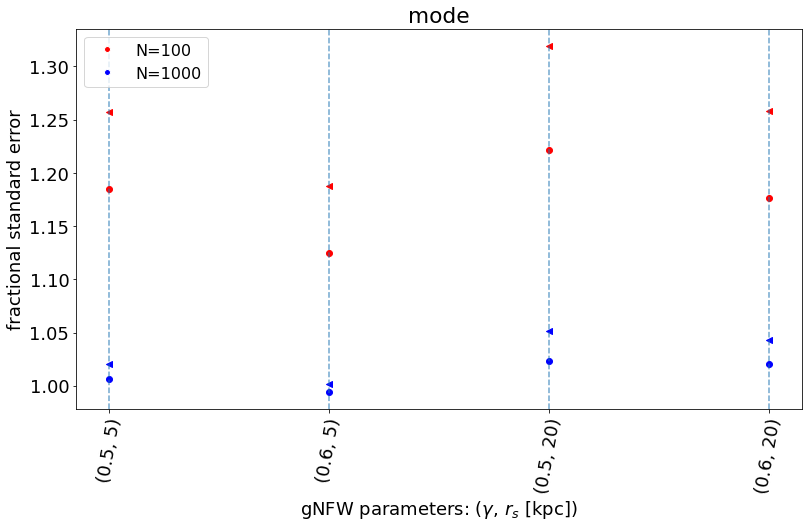

In [51]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, figsize=(13, 7))

PE = ["mode"]#, "mean", "median", "ML"]
for pe in PE:
    fig, ax = plot_FSE_pe(path, "final", pe, "o", fig, ax)
    plot_FSE_pe(path, "final_non_linear", pe, "<", fig, ax)
    #plot_FSE_pe(path, "final_non_linear_wider", pe, "s", fig, ax)
    
    props = dict(boxstyle='round', facecolor='grey', alpha=0.2)
    #ax.text(0.5, 0.08, r"$\sigma_T=10\%$ $\sigma_{\rm mass}=\sigma_{\rm radius}=\sigma_{\rm age}=30\%$", 
    #        transform=ax.transAxes, fontsize=18, bbox=props, verticalalignment='top')
    
    legend_elements = [#Line2D([0], [0], marker='o', color='w', markerfacecolor='k', label='Linear error propag.'),
                       #Line2D([0], [0], marker='<', color='w', markerfacecolor='k', label='Non-linear error propag.'),
                       Line2D([0], [0], marker='o', color='w', markerfacecolor='r', label='N=100'),
                       Line2D([0], [0], marker='o', color='w', markerfacecolor='b', label='N=1000')
                       ]

    ax.legend(handles=legend_elements, loc='upper left', fontsize=16)
    ax.set_ylabel("fractional standard error")
    ax.set_xlabel(r"gNFW parameters: ($\gamma$, $r_s$ [kpc])")
    
    #fig.savefig("FSE_MAP_sigma0.1.pdf", bbox_inches="tight")

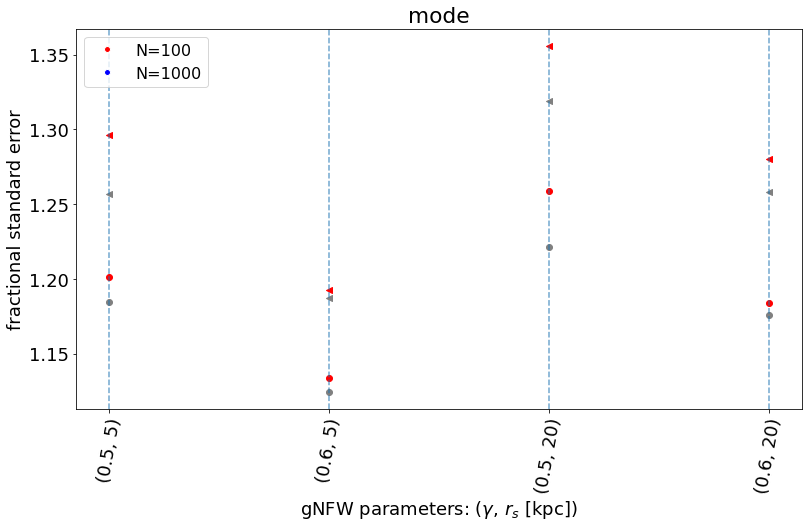

In [59]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, figsize=(13, 7))

PE = ["mode"]#, "mean", "median", "ML"]
for pe in PE:
    fig, ax = plot_FSE_pe(path, "final", pe, "o", fig, ax, color="grey")
    fig, ax = plot_FSE_pe(path, "final_extra_wider", pe, "o", fig, ax)
    plot_FSE_pe(path, "final_non_linear", pe, "<", fig, ax, color="grey")
    plot_FSE_pe(path, "final_non_linear_extra_wider", pe, "<", fig, ax)
    #plot_FSE_pe(path, "final_non_linear_wider", pe, "s", fig, ax)
    
    props = dict(boxstyle='round', facecolor='grey', alpha=0.2)
    #ax.text(0.5, 0.08, r"$\sigma_T=10\%$ $\sigma_{\rm mass}=\sigma_{\rm radius}=\sigma_{\rm age}=30\%$", 
    #        transform=ax.transAxes, fontsize=18, bbox=props, verticalalignment='top')
    
    legend_elements = [#Line2D([0], [0], marker='o', color='w', markerfacecolor='k', label='Linear error propag.'),
                       #Line2D([0], [0], marker='<', color='w', markerfacecolor='k', label='Non-linear error propag.'),
                       Line2D([0], [0], marker='o', color='w', markerfacecolor='r', label='N=100'),
                       Line2D([0], [0], marker='o', color='w', markerfacecolor='b', label='N=1000')
                       ]

    ax.legend(handles=legend_elements, loc='upper left', fontsize=16)
    ax.set_ylabel("fractional standard error")
    ax.set_xlabel(r"gNFW parameters: ($\gamma$, $r_s$ [kpc])")
    
    #fig.savefig("FSE_MAP_sigma0.1.pdf", bbox_inches="tight")

In [47]:
def plot_coverage_pe(path, ex, n, s, pe, fig=None, ax=None, color=None, ls=None):

    if not fig:
        fig, ax = plt.subplots(1, 1, figsize=(11, 5)) 
    #ax.set_title(pe)
    x=0
    if color is None:
        if n<200:
            color="red"
        else:
            color="blue"
    i = 0
    for _rs in rs:
        cove = []; x = [];
        for _g in gamma:
            try:
                data = np.genfromtxt(path + "statistics_" + ex +           
                         ("_N%i_sigma%.1f_gamma%.1frs%.1f"%(n, s, _g, _rs)), unpack=True) 
            except:
                data = np.genfromtxt(path + "statistics_" + ex +           
                         ("_N%i_sigma%.1f_gamma%.1frs%.1f"%(n, s, _g, _rs)), unpack=True)  
            if pe=="symmetric":                                                       
                low  = data[2]
                high = data[3]
            elif pe=="HPD":                                                       
                low  = data[7]
                high = data[8]
            elif pe=="LI":                                                       
                low  = data[10]
                high = data[11]
            else:                                                                  
                sys.exit("Interval not implemented!") 
                
            one = _g > low
            two = _g < high
            
            cove.append(len(np.where((one==True) & (two==True))[0])/len(data[0]))
            x.append(i); i+=1
                                    
        ax.plot(x, cove, color=color, ls=ls, lw=2.5)#, label="N=%i"%n)
    return fig, ax

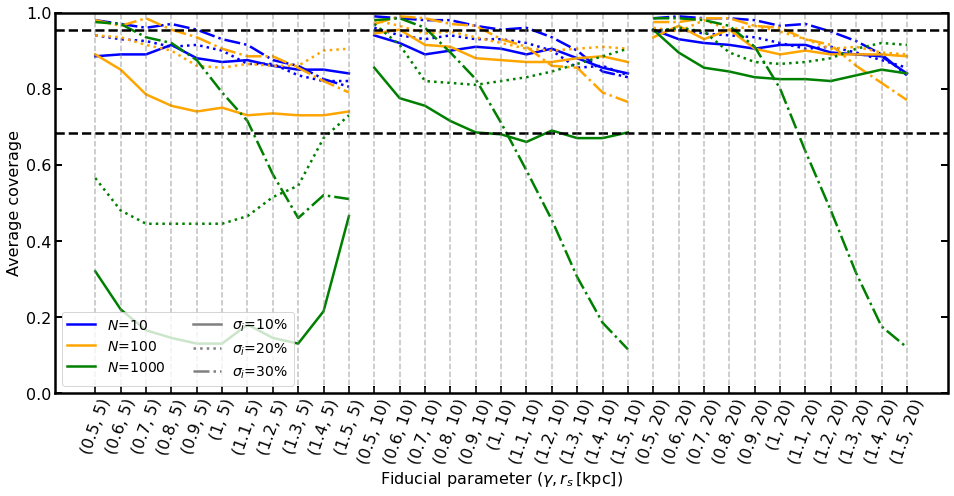

In [21]:
path = "/home/mariacst/exoplanets/results/power_law/older_BD/"
rc('font', family='times new roman', size=16.)

nBDs = 100
sigma = 0.1

gamma = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
rs    = [5, 10, 20]

x_axis = np.arange(0, 33)

from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, figsize=(16, 7))

pe = "LI"; ex="baseline_NL_olderBD"

plot_coverage_pe(path, ex, 10, 0.1, pe, fig, ax, color="blue", ls="-")
plot_coverage_pe(path, ex, 10, 0.2, pe, fig, ax, color="blue", ls=":")
plot_coverage_pe(path, ex, 10, 0.3, pe, fig, ax, color="blue", ls="-.")
plot_coverage_pe(path, ex, 100, 0.1, pe, fig, ax, color="orange", ls="-")
plot_coverage_pe(path, ex, 100, 0.2, pe, fig, ax, color="orange", ls=":")
plot_coverage_pe(path, ex, 100, 0.3, pe, fig, ax, color="orange", ls="-.")
plot_coverage_pe(path, ex, 1000, 0.1, pe, fig, ax, color="green", ls="-")
plot_coverage_pe(path, ex, 1000, 0.2, pe, fig, ax, color="green", ls=":")
plot_coverage_pe(path, ex, 1000, 0.3, pe, fig, ax, color="green", ls="-.")


ax.axhline(0.683, lw=2.5, ls="--", color="black"); ax.axhline(0.954, lw=2.5, ls="--", color="black")
ax.set_xticks(x_axis) 
#ax.set_xticklabels(['(1.2, 5)', '(1.4, 5)', '(1.5, 5)',
#                    '(1.2, 20)', '(1.4, 20)', '(1.5, 20)'
#                   ], rotation=80);
ax.set_xticklabels(['(0.5, 5)', '(0.6, 5)', '(0.7, 5)', '(0.8, 5)', '(0.9, 5)', '(1, 5)', '(1.1, 5)', '(1.2, 5)', '(1.3, 5)', '(1.4, 5)', '(1.5, 5)',
                    '(0.5, 10)', '(0.6, 10)', '(0.7, 10)', '(0.8, 10)', '(0.9, 10)', '(1, 10)', '(1.1, 10)', '(1.2, 10)', '(1.3, 10)', '(1.4, 10)', '(1.5, 10)',
                    '(0.5, 20)', '(0.6, 20)', '(0.7, 20)', '(0.8, 20)', '(0.9, 20)', '(1, 20)', '(1.1, 20)', '(1.2, 20)', '(1.3, 20)', '(1.4, 20)', 
                    '(1.5, 20)'], rotation=70)
ax.set_ylim(0., 1.)
ax.set_ylabel("Average coverage"); ax.set_xlabel(r"Fiducial parameter $(\gamma, r_s{\,\rm [kpc]})$")
for x in x_axis:
    ax.axvline(x, ls="--", color="grey", alpha=0.5)
    
legend_elements = [Line2D([0], [0], color='blue', lw=2.5, label='$N$=10'),
                   Line2D([0], [0], color='orange', lw=2.5, label='$N$=100'),
                   Line2D([0], [0], color='green', lw=2.5, label='$N$=1000'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle="-", label='$\sigma_i$=10%'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle=":", label='$\sigma_i$=20%'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle="-.", label='$\sigma_i$=30%')]

ax.legend(handles=legend_elements, ncol=2, loc='lower left', fontsize=14)

ax.tick_params(which='major',direction="in",width=2.,length=7,right=True,top=False,pad=3)
ax.tick_params(which='minor',direction="in",width=2.,length=4,right=True,top=False)

fig.savefig("coverage2_" + ex + pe + ".pdf", transparent=True, bbox_inches="tight")

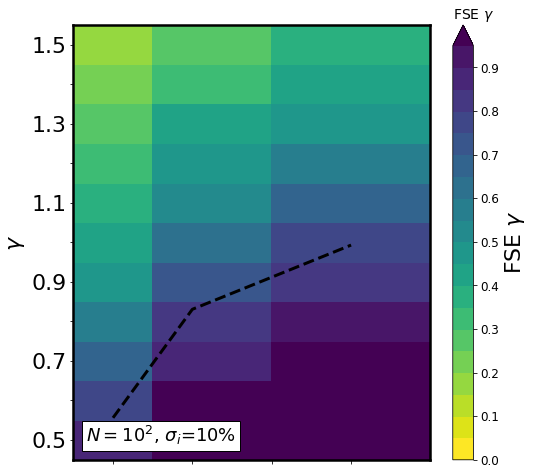

In [12]:
path = "/home/mariacst/exoplanets/results/power_law/"
ex   = "T650_NL_log"

pe = "ML"
    
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
cs = grid_FSE(path, 100, 0.1,  ex, ax, pe, ylabel=True, xlabel=False)

#ax[0, 0].set_title(pe)
ax.set_yticklabels(['0.5', '', '0.7', '', '0.9', '', '1.1', '', '1.3', '', '1.5'])

#fig.subplots_adjust(wspace=0.1, hspace=0.1)
cbar = fig.colorbar(cs)
cbar.set_label(r"FSE $\gamma^{{}}$".format(pe))



cbar.ax.tick_params(labelsize=12)
cbar.ax.set_title(r"FSE $\gamma$", size=14., loc="left")

nBDs=100; sigma=0.1; f=1.
rs = [5., 10., 20.]; UL = []; gamma_UL_2sigma_minus=[]
gamma_UL_2sigma_plus=[]; gamma_UL_1sigma_minus=[]; gamma_UL_1sigma_plus=[]

path="../python/data_UL/"
ex="T650"

for _rs in rs:
    data = np.genfromtxt(path + "UL_" + ex + "_nBDs%i_sigma%.1f_f%.1f_steps200_rs%.1f_gNFW.dat"
                         %(nBDs, sigma, f, _rs), unpack=True)
    UL.append(np.median(data)); gamma_UL_1sigma_minus.append(np.percentile(data, 15.85))
    gamma_UL_1sigma_plus.append(np.percentile(data, 84.15)); gamma_UL_2sigma_plus.append(np.percentile(data, 97.7))
    gamma_UL_2sigma_minus.append(np.percentile(data, 2.30))
    
ax.plot(rs, UL, color="k", lw=3., ls="--")

In [4]:
import utils_plots; import importlib
importlib.reload(utils_plots)
from utils_plots import grid_FSE

OSError: /home/mariacst/exoplanets/results/power_law/statistics_2sigma_baseline_log_N100_sigma0.1_gamma0.5rs5.0 not found.

findfont: Font family ['times new roman'] not found. Falling back to DejaVu Sans.


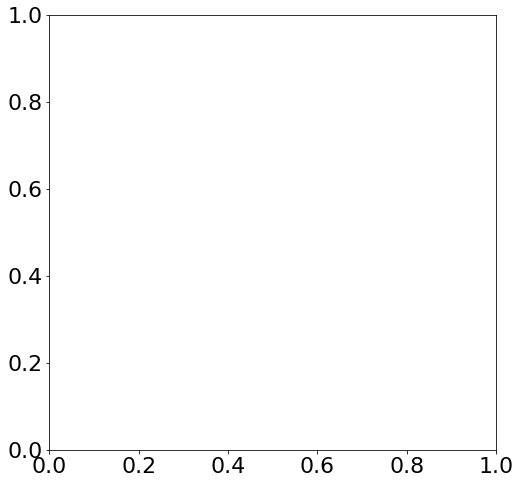

In [5]:
path = "/home/mariacst/exoplanets/results/power_law/"
ex   = "baseline_log"

pe = "HDE"
    
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
cs = grid_FSE(path, 100, 0.1,  ex, ax, pe, ylabel=True, xlabel=False)

#ax[0, 0].set_title(pe)
ax.set_yticklabels(['0.5', '', '0.7', '', '0.9', '', '1.1', '', '1.3', '', '1.5'])

#fig.subplots_adjust(wspace=0.1, hspace=0.1)
cbar = fig.colorbar(cs)
cbar.set_label(r"FSE $\gamma^{{}}$".format(pe))



cbar.ax.tick_params(labelsize=12)
cbar.ax.set_title(r"FSE $\gamma$", size=14., loc="left")

# Comparisons:
- between gNFW & power-law
- between =! velocity dispersions

In [17]:
from utils_plots import FSE_f_gamma_rs_gNFW, FSE_f_gamma_rs

In [18]:
def FSE_comparison(N, sigma):
    path = "/home/mariacst/exoplanets/results/gNFW/"
    xi, yi, zi       = FSE_f_gamma_rs_gNFW(path, N, sigma, "T650_NL_gNFW_longerPriorG", _gamma=True) 
    path = "/home/mariacst/exoplanets/results/power_law/"
    xiPL, yiPL, ziPL = FSE_f_gamma_rs(path, N, sigma, "T650_NL_log", PE="ML")
    return (np.ravel(ziPL)-np.ravel(zi))

FSE_comparison(100, 0.1).shape

(33,)

/home/mariacst/exoplanets/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:77: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "background" which is no longer supported as of 3.3 and will become an error two minor releases later


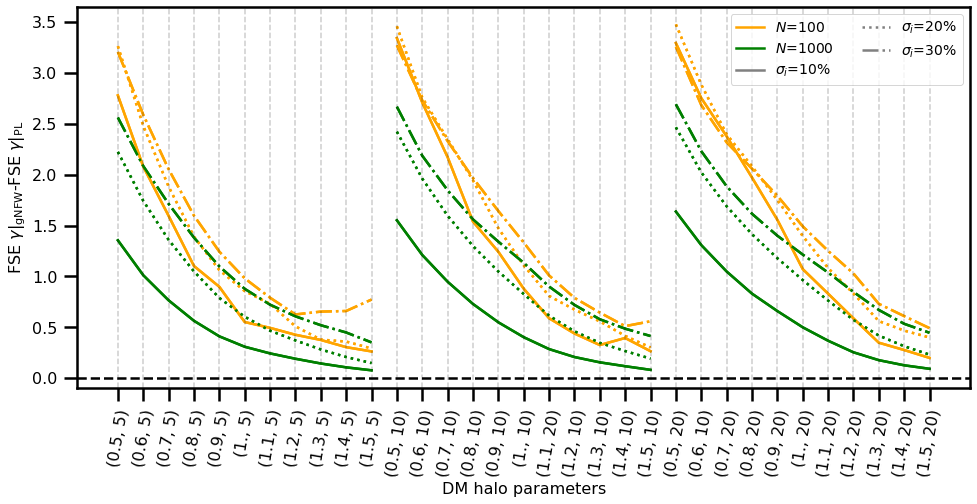

In [18]:
from utils_plots import FSE_f_gamma_rs_gNFW, FSE_f_gamma_rs


rc('font', family='times new roman', size=16.)
pe="ML"

def plot_FSE_comparison(N, sigma, color="red", ls="-"):
    path = "/home/mariacst/exoplanets/results/gNFW/"
    xi, yi, zi       = FSE_f_gamma_rs_gNFW(path, N, sigma, "T650_NL_gNFW_longerPriorG", _gamma=True) 
    path = "/home/mariacst/exoplanets/results/power_law/"
    xiPL, yiPL, ziPL = FSE_f_gamma_rs(path, N, sigma, "T650_NL_log", PE=pe)
    
    diff = np.ravel(zi) - np.ravel(ziPL)
    
    ax.plot(x_axis[:11], diff[:11], lw=2.5, color=color, ls=ls)
    ax.plot(x_axis[11:22], diff[11:22], lw=2.5, color=color, ls=ls)
    ax.plot(x_axis[22:], diff[22:], lw=2.5, color=color, ls=ls)
    
    return

gamma = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
rs    = [5, 10, 20]
x1    = np.linspace(0, 1, 33);

x_axis = np.arange(0, 33)

from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, figsize=(16, 7))


plot_FSE_comparison(100, 0.1, color="orange", ls="-")
plot_FSE_comparison(100, 0.2, color="orange", ls=":")
plot_FSE_comparison(100, 0.3, color="orange", ls="-.")
plot_FSE_comparison(1000, 0.1, color="green", ls="-")
plot_FSE_comparison(1000, 0.2, color="green", ls=":")
plot_FSE_comparison(1000, 0.3, color="green", ls="-.")

plot_FSE_comparison(100, 0.1,color="orange", ls="-")
plot_FSE_comparison(100, 0.2,color="orange", ls=":")
plot_FSE_comparison(100, 0.3,color="orange", ls="-.")
plot_FSE_comparison(1000, 0.1, color="green", ls="-")
plot_FSE_comparison(1000, 0.2, color="green", ls=":")
plot_FSE_comparison(1000, 0.3, color="green", ls="-.")



for axis in ['top','bottom','left','right']:                                    
    ax.spines[axis].set_linewidth(2.5) 
ax.tick_params(which='major',direction="out",width=2.5,length=13,right=False,top=False,pad=7)

for i in x_axis:
    ax.axvline(i, ls="--", alpha=0.2, color="k")


ax.set_xticks(x_axis) 
ax.set_xticklabels(['(0.5, 5)', '(0.6, 5)', '(0.7, 5)', '(0.8, 5)', '(0.9, 5)', 
                        '(1., 5)', '(1.1, 5)', '(1.2, 5)', '(1.3, 5)', '(1.4, 5)', '(1.5, 5)',
                       '(0.5, 10)', '(0.6, 10)', '(0.7, 10)', '(0.8, 10)', '(0.9, 10)', 
                        '(1., 10)', '(1.1, 20)', '(1.2, 10)', '(1.3, 10)', '(1.4, 10)', '(1.5, 10)', 
                        '(0.5, 20)', '(0.6, 10)', '(0.7, 20)', '(0.8, 20)', '(0.9, 20)', 
                        '(1., 20)', '(1.1, 20)', '(1.2, 20)', '(1.3, 20)', '(1.4, 20)', '(1.5, 20)', 
                       ], 
                   rotation=80);

legend_elements = [Line2D([0], [0], color='orange', lw=2.5, label='$N$=100'),
                   Line2D([0], [0], color='green', lw=2.5, label='$N$=1000'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle="-", label='$\sigma_i$=10%'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle=":", label='$\sigma_i$=20%'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle="-.", label='$\sigma_i$=30%')]

ax.axhline(0., lw=2.5, color="k", ls="--")

ax.set_ylabel(r"FSE $\gamma|_{\rm gNFW}$-FSE $\gamma|_{\rm PL}$"); ax.set_xlabel("DM halo parameters")
ax.legend(handles=legend_elements, ncol=2, loc='upper right', fontsize=14)
#ax.set_title(r"ML, $\sigma=%i$"%(int(sigma*100)) + "$\%$")
fig.savefig("T650_NL_comparison.png", bbox_inches="tight", background="transparent")

Text(0.5, 0, 'DM halo parameters')

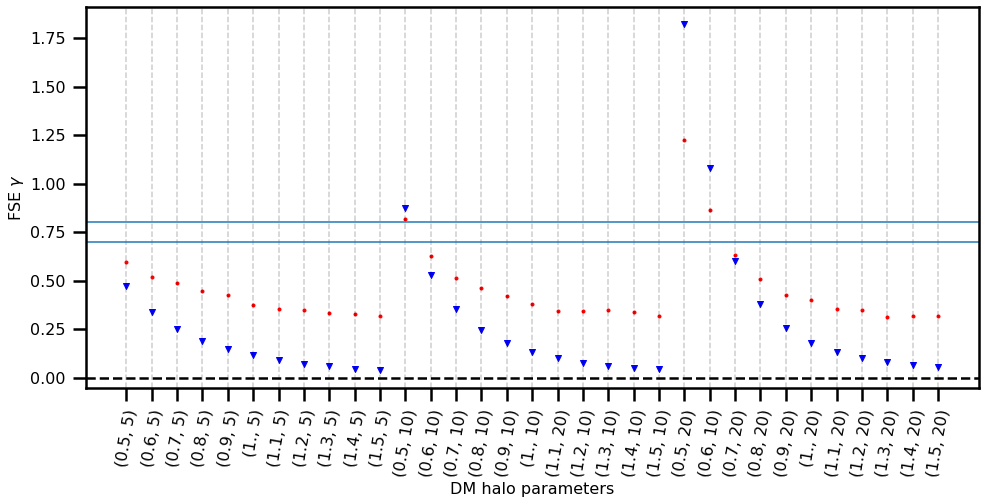

In [105]:
from utils_plots import FSE_f_gamma_rs_gNFW, FSE_f_gamma_rs


rc('font', family='times new roman', size=16.)

def plot_FSE_comparison(N, sigma, color="red", ls="-"):
    path = "/home/mariacst/exoplanets/results/gNFW/"
    xi, yi, zi       = FSE_f_gamma_rs_gNFW(path, N, sigma, "baseline_NL_gNFW", _gamma=True) 
    path = "/home/mariacst/exoplanets/results/power_law/"
    xiPL, yiPL, ziPL = FSE_f_gamma_rs(path, N, sigma, "baseline_NL_log", PE=pe)
    
    diff = np.ravel(zi) - np.ravel(ziPL)
    
    ax.plot(x_axis[:11], diff[:11], lw=2.5, color=color, ls=ls)
    ax.plot(x_axis[11:22], diff[11:22], lw=2.5, color=color, ls=ls)
    ax.plot(x_axis[22:], diff[22:], lw=2.5, color=color, ls=ls)
    
    return

gamma = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
rs    = [5, 10, 20]
x1    = np.linspace(0, 1, 33);

x_axis = np.arange(0, 33)

from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, figsize=(16, 7))

path = "/home/mariacst/exoplanets/results/gNFW/"
xi, yi, zi = FSE_f_gamma_rs_gNFW(path, 1000, 0.2, "baseline_NL_gNFW", _gamma=True) 
ax.scatter(x_axis, np.ravel(zi), color="red", marker=".")

path = "/home/mariacst/exoplanets/results/power_law/"
xiPL, yiPL, ziPL = FSE_f_gamma_rs(path, 1000, 0.2, "baseline_NL_log", PE=pe)
ax.scatter(x_axis, np.ravel(ziPL), color="blue", marker="v")


for axis in ['top','bottom','left','right']:                                    
    ax.spines[axis].set_linewidth(2.5) 
ax.tick_params(which='major',direction="out",width=2.5,length=13,right=False,top=False,pad=7)

for i in x_axis:
    ax.axvline(i, ls="--", alpha=0.2, color="k")


ax.set_xticks(x_axis) 
ax.set_xticklabels(['(0.5, 5)', '(0.6, 5)', '(0.7, 5)', '(0.8, 5)', '(0.9, 5)', 
                        '(1., 5)', '(1.1, 5)', '(1.2, 5)', '(1.3, 5)', '(1.4, 5)', '(1.5, 5)',
                       '(0.5, 10)', '(0.6, 10)', '(0.7, 10)', '(0.8, 10)', '(0.9, 10)', 
                        '(1., 10)', '(1.1, 20)', '(1.2, 10)', '(1.3, 10)', '(1.4, 10)', '(1.5, 10)', 
                        '(0.5, 20)', '(0.6, 10)', '(0.7, 20)', '(0.8, 20)', '(0.9, 20)', 
                        '(1., 20)', '(1.1, 20)', '(1.2, 20)', '(1.3, 20)', '(1.4, 20)', '(1.5, 20)', 
                       ], 
                   rotation=80);

legend_elements = [Line2D([0], [0], color='orange', lw=2.5, label='$N$=100'),
                   Line2D([0], [0], color='green', lw=2.5, label='$N$=1000'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle="-", label='$\sigma_i$=10%'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle=":", label='$\sigma_i$=20%'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle="-.", label='$\sigma_i$=30%')]

ax.axhline(0., lw=2.5, color="k", ls="--")
ax.axhline(0.7); ax.axhline(0.8)

ax.set_ylabel(r"FSE $\gamma$"); ax.set_xlabel("DM halo parameters")
#ax.legend(handles=legend_elements, ncol=2, loc='lower left', fontsize=14)

/home/mariacst/exoplanets/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:75: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "background" which is no longer supported as of 3.3 and will become an error two minor releases later


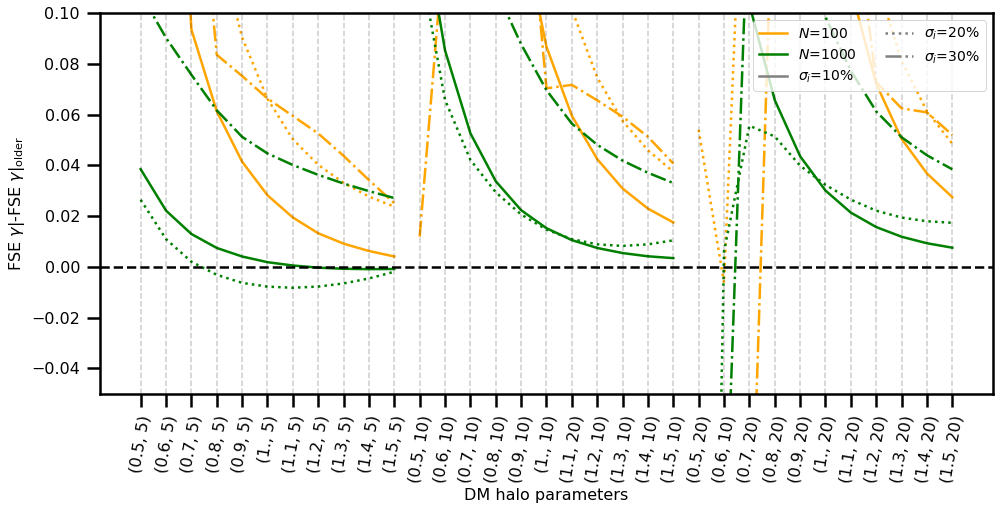

In [17]:
from utils_plots import FSE_f_gamma_rs_gNFW, FSE_f_gamma_rs


rc('font', family='times new roman', size=16.)
pe="ML"

def plot_FSE_comparison(N, sigma, color="red", ls="-"):
    path = "/home/mariacst/exoplanets/results/power_law/"
    xi, yi, zi       = FSE_f_gamma_rs(path, N, sigma, "baseline_NL_log", PE=pe) 
    path = "/home/mariacst/exoplanets/results/power_law/older_BD/"
    xiPL, yiPL, ziPL = FSE_f_gamma_rs(path, N, sigma, "baseline_NL_olderBD", PE=pe)
    
    diff = np.ravel(zi) - np.ravel(ziPL)
    
    ax.plot(x_axis[:11], diff[:11], lw=2.5, color=color, ls=ls)
    ax.plot(x_axis[11:22], diff[11:22], lw=2.5, color=color, ls=ls)
    ax.plot(x_axis[22:], diff[22:], lw=2.5, color=color, ls=ls)
    
    return

gamma = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
rs    = [5, 10, 20]
x1    = np.linspace(0, 1, 33);

x_axis = np.arange(0, 33)

from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, figsize=(16, 7))



#plot_FSE_comparison(10, 0.1, color="blue", ls="-")
#plot_FSE_comparison(10, 0.2, color="blue", ls=":")
#plot_FSE_comparison(10, 0.3, color="blue", ls="-.")
plot_FSE_comparison(100, 0.1, color="orange", ls="-")
plot_FSE_comparison(100, 0.2, color="orange", ls=":")
plot_FSE_comparison(100, 0.3, color="orange", ls="-.")
plot_FSE_comparison(1000, 0.1, color="green", ls="-")
plot_FSE_comparison(1000, 0.2, color="green", ls=":")
plot_FSE_comparison(1000, 0.3, color="green", ls="-.")



for axis in ['top','bottom','left','right']:                                    
    ax.spines[axis].set_linewidth(2.5) 
ax.tick_params(which='major',direction="out",width=2.5,length=13,right=False,top=False,pad=7)

for i in x_axis:
    ax.axvline(i, ls="--", alpha=0.2, color="k")


ax.set_xticks(x_axis) 
ax.set_xticklabels(['(0.5, 5)', '(0.6, 5)', '(0.7, 5)', '(0.8, 5)', '(0.9, 5)', 
                        '(1., 5)', '(1.1, 5)', '(1.2, 5)', '(1.3, 5)', '(1.4, 5)', '(1.5, 5)',
                       '(0.5, 10)', '(0.6, 10)', '(0.7, 10)', '(0.8, 10)', '(0.9, 10)', 
                        '(1., 10)', '(1.1, 20)', '(1.2, 10)', '(1.3, 10)', '(1.4, 10)', '(1.5, 10)', 
                        '(0.5, 20)', '(0.6, 10)', '(0.7, 20)', '(0.8, 20)', '(0.9, 20)', 
                        '(1., 20)', '(1.1, 20)', '(1.2, 20)', '(1.3, 20)', '(1.4, 20)', '(1.5, 20)', 
                       ], 
                   rotation=80);

legend_elements = [Line2D([0], [0], color='orange', lw=2.5, label='$N$=100'),
                   Line2D([0], [0], color='green', lw=2.5, label='$N$=1000'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle="-", label='$\sigma_i$=10%'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle=":", label='$\sigma_i$=20%'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle="-.", label='$\sigma_i$=30%')]

ax.axhline(0., lw=2.5, color="k", ls="--")
ax.set_ylim(-0.05, 0.1)

ax.set_ylabel(r"FSE $\gamma|$-FSE $\gamma|_{\rm older}$"); ax.set_xlabel("DM halo parameters")
ax.legend(handles=legend_elements, ncol=2, loc='upper right', fontsize=14)
#ax.set_title(r"ML, $\sigma=%i$"%(int(sigma*100)) + "$\%$")
fig.savefig("baseline_NL_comparison_age_zoom.png", bbox_inches="tight", background="transparent")

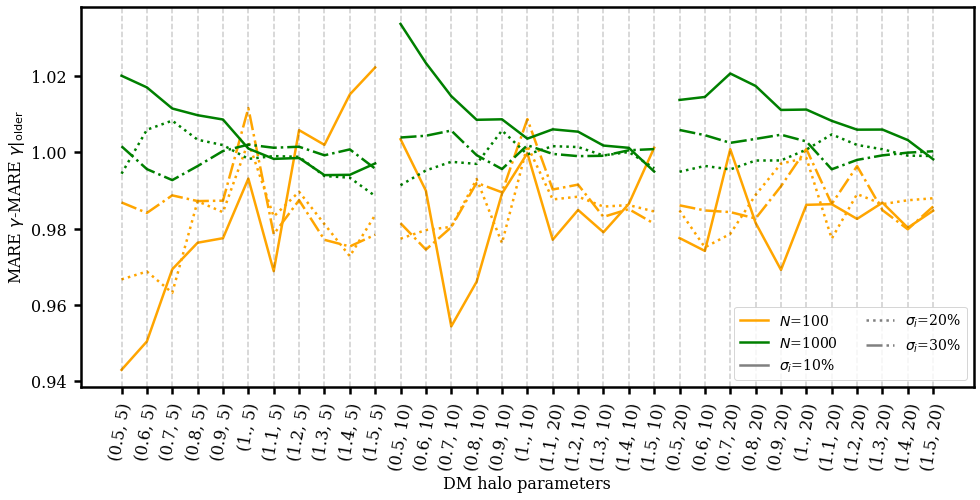

In [12]:
def MARE_f_gamma_rs(filepath, nBDs, sigma, ex, PE="ML", upTo=None):                           
    # grid points                                                                  
    f     = 1.                                                                     
    rs    = np.array([5., 10., 20.])                                               
    gamma = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1, 1.2, 1.3, 1.4, 1.5])        
                                                                                   
    MARE = [];                                                                     
    for _rs in rs:                                                                 
        for _g in gamma:                                                           
            data = np.genfromtxt(filepath + "statistics_" + ex +                   
                                 ("_N%i_sigma%.1f_gamma%.1frs%.1f"                 
                                  %(nBDs, sigma, _g, _rs)), unpack=True)           
            if PE=="median":                                                       
                pe = data[1]                                                       
            elif PE=="mode1":                                                      
                pe = data[4]                                                       
            elif PE=="mode2":                                                      
                pe = data[5]                                                       
            elif PE=="mode3":                                                      
                pe = data[6]                                                       
            elif PE=="mean":                                                       
                pe = data[0]                                                       
            elif PE=="ML":                                                         
                pe = data[9]                                                       
            else:                                                                  
                sys.exit("Point estimate not implemented!")                        
            
            if upTo==None:
                rank=len(data[0]);                                         
                MARE.append(1/rank*np.sum(np.abs(pe - _g)/_g)) 
            else:
                rank=len(data[0][:upTo]);                                        
                MARE.append(1/rank*np.sum(np.abs(pe[:upTo] - _g)/_g))
                #print(rank, len(pe[:upTo]))
                                                                                   
    xi = np.array([2.5, 7.5, 15, 25])                                              
    yi = np.array([0.45, 0.55, 0.65, 0.75, 0.85, 0.95,                             
                   1.05, 1.15, 1.25, 1.35, 1.45, 1.55])                            
    xi, yi = np.meshgrid(xi, yi, indexing="ij")                                    
                                                                                   
    zi   = np.array(MARE).reshape(len(rs), len(gamma))                             
    # return                                                                       
    return xi, yi, zi 


rc('font', family='serif', size=16.)
pe="ML"

def plot_MARE_comparison(N, sigma, color="red", ls="-"):
    path = "/home/mariacst/exoplanets/results/power_law/older_BD/"
    xi, yi, zi       = MARE_f_gamma_rs(path, N, sigma, "T650_NL_olderBD", PE=pe) 
    path = "/home/mariacst/exoplanets/results/power_law/older_BD/"
    xiPL, yiPL, ziPL = MARE_f_gamma_rs(path, N, sigma, "T650_NL_olderBD", PE=pe, upTo=100)
    
    diff = np.ravel(zi)/np.ravel(ziPL)
    
    ax.plot(x_axis[:11], diff[:11], lw=2.5, color=color, ls=ls)
    ax.plot(x_axis[11:22], diff[11:22], lw=2.5, color=color, ls=ls)
    ax.plot(x_axis[22:], diff[22:], lw=2.5, color=color, ls=ls)
    
    return

gamma = [0.5]#, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
rs    = [5, 10, 20]
x1    = np.linspace(0, 1, 33);

x_axis = np.arange(0, 33)

from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, figsize=(16, 7))


plot_MARE_comparison(100, 0.1, color="orange", ls="-")
plot_MARE_comparison(100, 0.2, color="orange", ls=":")
plot_MARE_comparison(100, 0.3, color="orange", ls="-.")
plot_MARE_comparison(1000, 0.1, color="green", ls="-")
plot_MARE_comparison(1000, 0.2, color="green", ls=":")
plot_MARE_comparison(1000, 0.3, color="green", ls="-.")



for axis in ['top','bottom','left','right']:                                    
    ax.spines[axis].set_linewidth(2.5) 
ax.tick_params(which='major',direction="out",width=2.5,length=7,right=False,top=False,pad=7)

for i in x_axis:
    ax.axvline(i, ls="--", alpha=0.2, color="k")


ax.set_xticks(x_axis) 
ax.set_xticklabels(['(0.5, 5)', '(0.6, 5)', '(0.7, 5)', '(0.8, 5)', '(0.9, 5)', 
                        '(1., 5)', '(1.1, 5)', '(1.2, 5)', '(1.3, 5)', '(1.4, 5)', '(1.5, 5)',
                       '(0.5, 10)', '(0.6, 10)', '(0.7, 10)', '(0.8, 10)', '(0.9, 10)', 
                        '(1., 10)', '(1.1, 20)', '(1.2, 10)', '(1.3, 10)', '(1.4, 10)', '(1.5, 10)', 
                        '(0.5, 20)', '(0.6, 10)', '(0.7, 20)', '(0.8, 20)', '(0.9, 20)', 
                        '(1., 20)', '(1.1, 20)', '(1.2, 20)', '(1.3, 20)', '(1.4, 20)', '(1.5, 20)', 
                       ], 
                   rotation=80);

legend_elements = [Line2D([0], [0], color='orange', lw=2.5, label='$N$=100'),
                   Line2D([0], [0], color='green', lw=2.5, label='$N$=1000'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle="-", label='$\sigma_i$=10%'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle=":", label='$\sigma_i$=20%'),
                   Line2D([0], [0], color='grey', lw=2.5, linestyle="-.", label='$\sigma_i$=30%')]

#ax.axhline(0., lw=2.5, color="k", ls="--")
#ax.set_ylim(0., 0.1)

ax.set_ylabel(r"MARE $\gamma$-MARE $\gamma|_{\rm older}$"); ax.set_xlabel("DM halo parameters")
ax.legend(handles=legend_elements, ncol=2, loc='lower right', fontsize=14)
#ax.set_title(r"ML, $\sigma=%i$"%(int(sigma*100)) + "$\%$")
#fig.savefig("T650_NL_MAREcomparison_olderBD.png", bbox_inches="tight", background="transparent")

# Violin plot

In [19]:
import pandas as pd
import seaborn as sns

x_axis = np.arange(0, 33)

df = pd.DataFrame(columns=("x", "gamma_ML"))

gamma = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
rs    = [5, 10, 20]

df

n=100; s=0.1; ex="baseline_NL_olderBD"

path = "/home/mariacst/exoplanets/results/power_law/older_BD/"
i=-1
for _rs in rs:
    for g in gamma:
        i+=1
        data = np.genfromtxt(path + "statistics_" + ex +           
                   ("_N%i_sigma%.1f_gamma%.1frs%.1f"%(n, s, g, _rs)), unpack=True) 
                                                     
        _pe = data[9]
        
        df2 = pd.DataFrame({"x":(np.ones(len(_pe))*x_axis[i]).tolist(), "diff":(_pe - g).tolist()})
        
        df = df.append(df2)

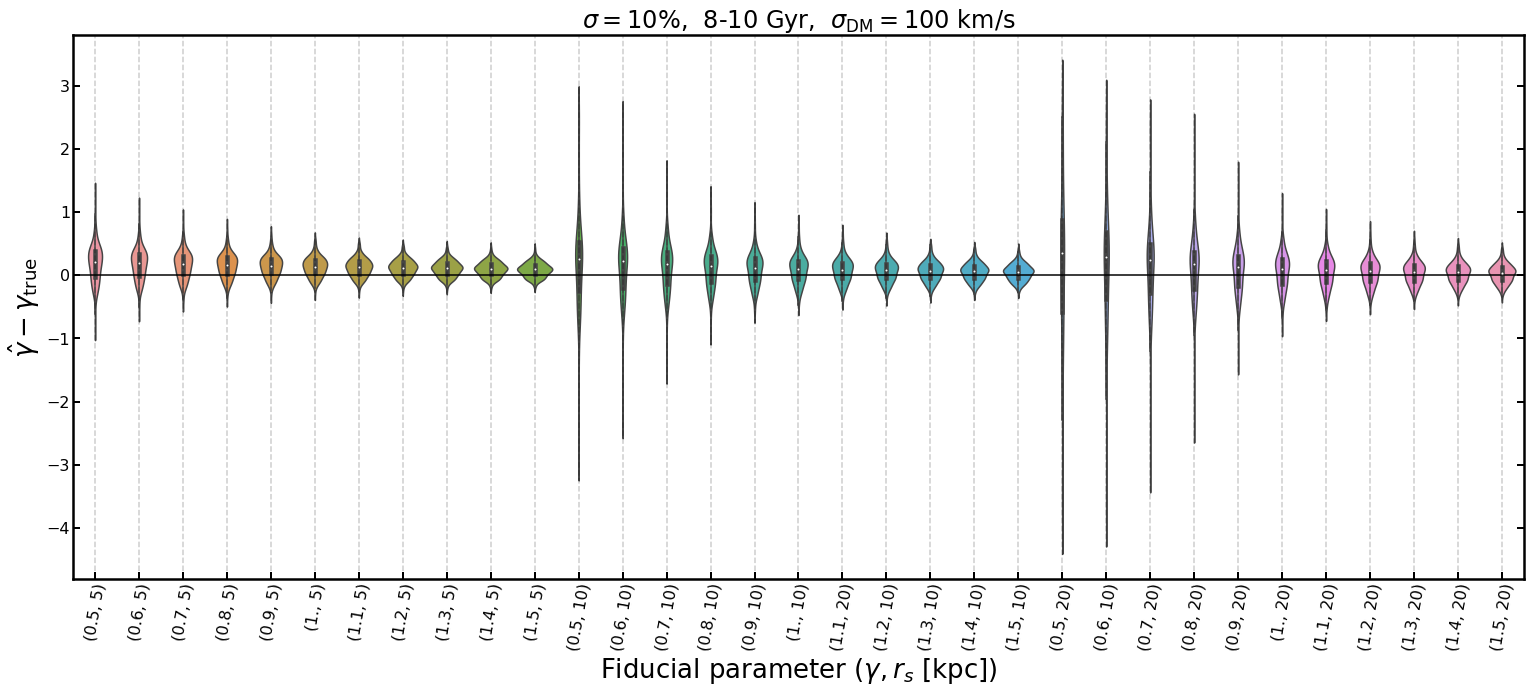

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(26, 10))

sns.violinplot(data=df, x="x", y="diff", ax=ax)

for axis in ['top','bottom','left','right']:                                    
    ax.spines[axis].set_linewidth(2.5) 

ax.set_xticks(x_axis)
ax.set_xticklabels(['(0.5, 5)', '(0.6, 5)', '(0.7, 5)', '(0.8, 5)', '(0.9, 5)', 
                        '(1., 5)', '(1.1, 5)', '(1.2, 5)', '(1.3, 5)', '(1.4, 5)', '(1.5, 5)',
                       '(0.5, 10)', '(0.6, 10)', '(0.7, 10)', '(0.8, 10)', '(0.9, 10)', 
                        '(1., 10)', '(1.1, 20)', '(1.2, 10)', '(1.3, 10)', '(1.4, 10)', '(1.5, 10)', 
                        '(0.5, 20)', '(0.6, 10)', '(0.7, 20)', '(0.8, 20)', '(0.9, 20)', 
                        '(1., 20)', '(1.1, 20)', '(1.2, 20)', '(1.3, 20)', '(1.4, 20)', '(1.5, 20)', 
                       ], 
                   rotation=80);
ax.axhline(0., color="k"); ax.set_ylabel(r"$\hat{\gamma}-\gamma_{\rm true}$", fontsize=26)
ax.set_xlabel(r"Fiducial parameter ($\gamma, r_s$ [kpc])", fontsize=26)
for i in x_axis:
    ax.axvline(i, ls="--", alpha=0.2, color="k")
ax.tick_params(which='major',direction="in",width=2.,length=7,right=True,top=False,pad=3)
ax.tick_params(which='minor',direction="in",width=2.,length=4,right=True,top=False)
ax.set_title(r"$\sigma=$10%,  8-10 Gyr,  $\sigma_{\rm DM}=100$ km/s", fontsize=24)

fig.savefig("violin_baseline_NL_older_sigma0.1_1.png", bbox_inches="tight")

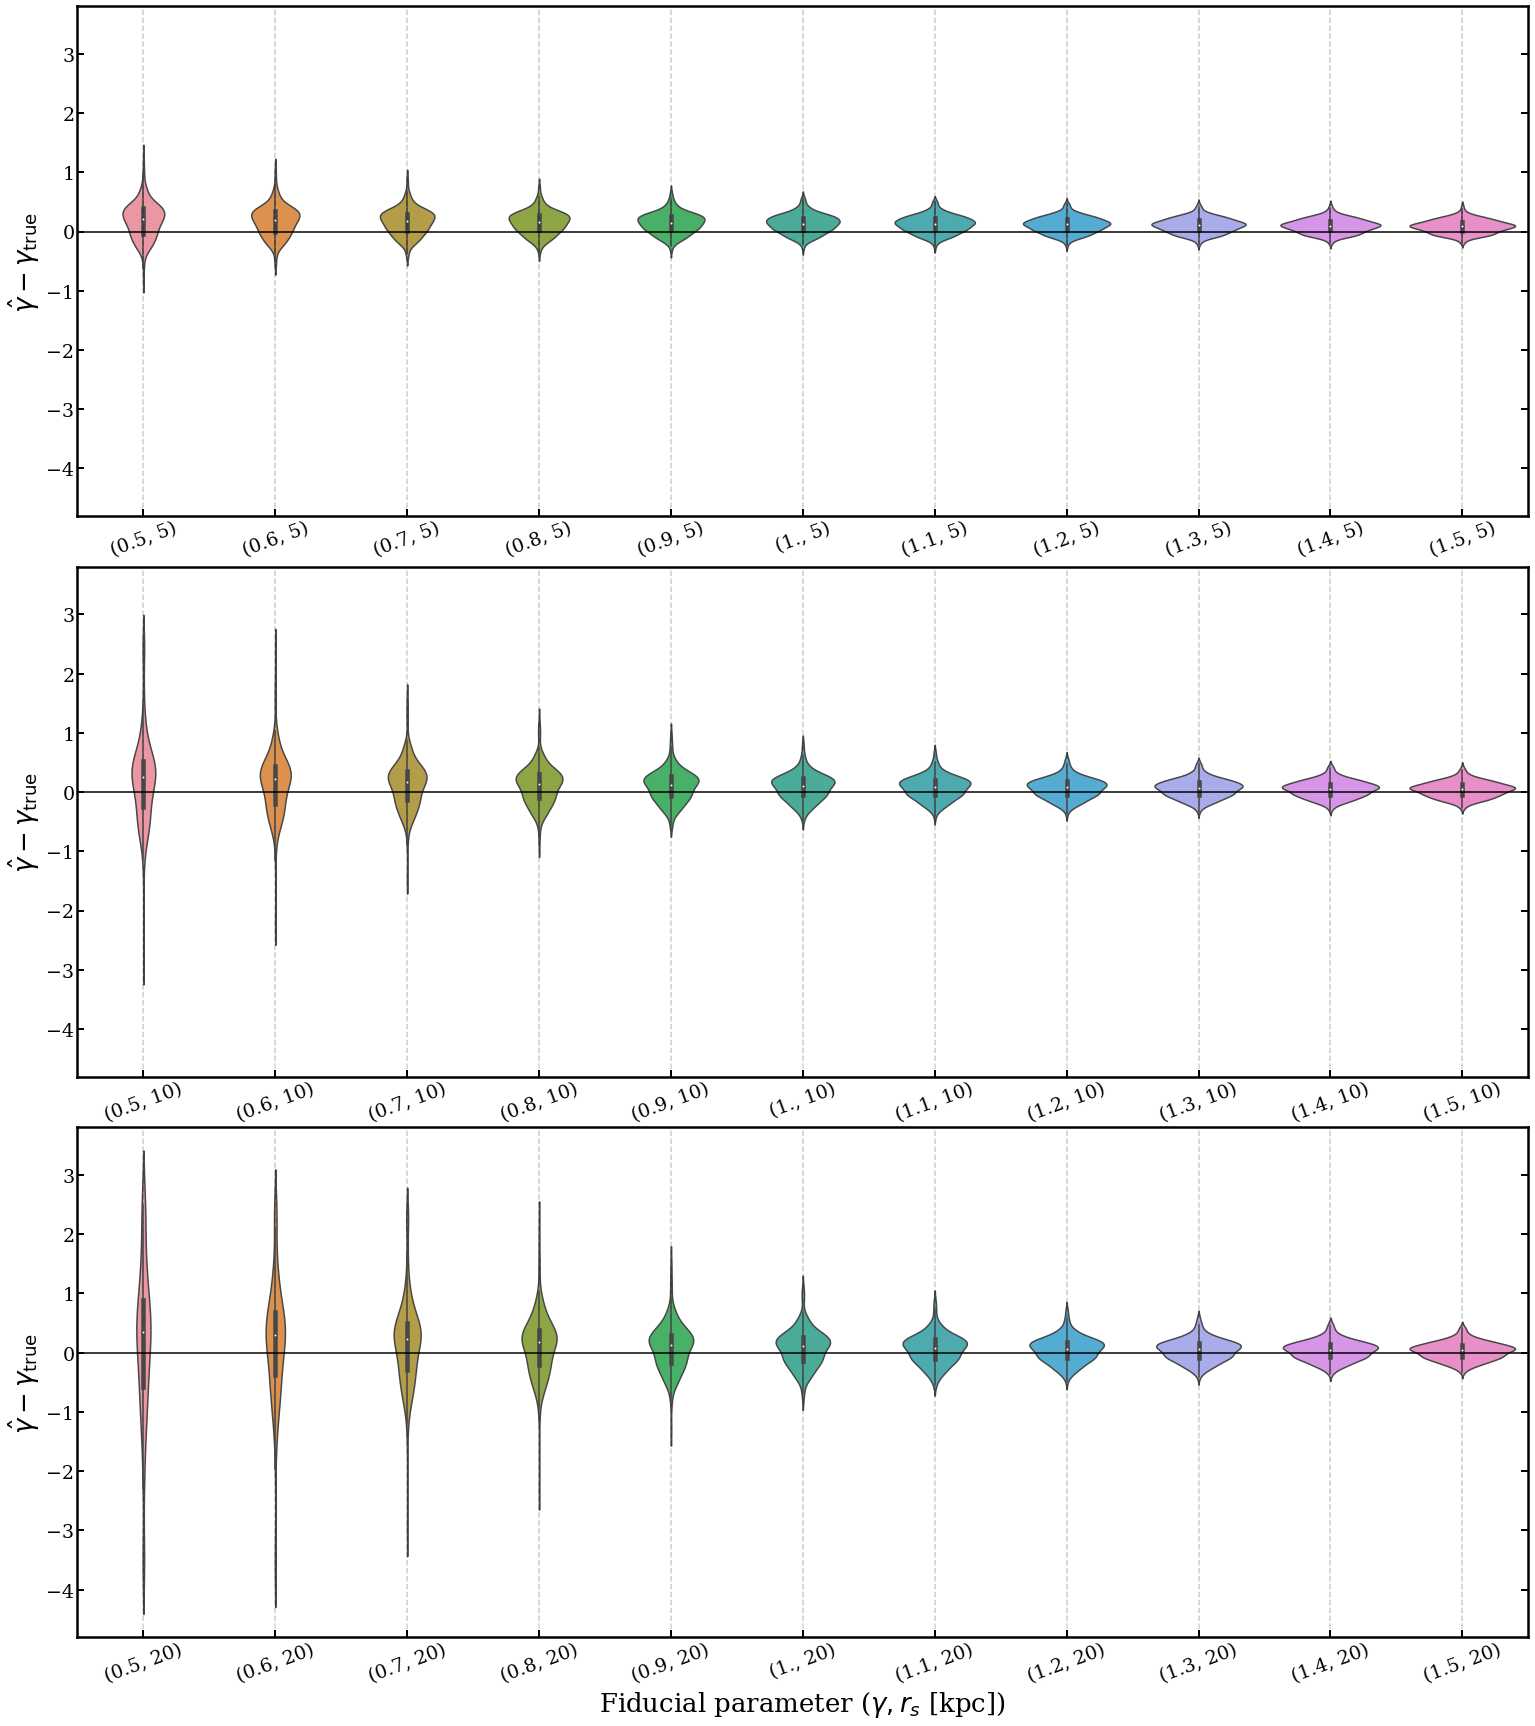

In [49]:
fig, ax = plt.subplots(3, 1, figsize=(26, 30), sharey=True)

sns.violinplot(data=df[df.x<11], x="x", y="diff", ax=ax[0])

ax[0].set_xticks(x_axis[:11])
ax[0].set_xticklabels(['(0.5, 5)', '(0.6, 5)', '(0.7, 5)', '(0.8, 5)', '(0.9, 5)', 
                        '(1., 5)', '(1.1, 5)', '(1.2, 5)', '(1.3, 5)', '(1.4, 5)', '(1.5, 5)'],
                      rotation=20);
ax[0].axhline(0., color="k"); ax[0].set_ylabel(r"$\hat{\gamma}-\gamma_{\rm true}$", fontsize=26)
ax[0].tick_params(which='major',direction="in",width=2.,length=7,right=True,top=False,pad=3)
ax[0].tick_params(which='minor',direction="in",width=2.,length=4,right=True,top=False)
ax[0].set_xlabel(" ", fontsize=18)

for i in x_axis[:11]:
    ax[0].axvline(i, ls="--", alpha=0.2, color="k")
    ax[1].axvline(i, ls="--", alpha=0.2, color="k")
    ax[2].axvline(i, ls="--", alpha=0.2, color="k")

sns.violinplot(data=df[(df.x>=11) & (df.x<22)], x="x", y="diff", ax=ax[1])

ax[1].set_xticks(x_axis[:11])
ax[1].set_xticklabels(['(0.5, 10)', '(0.6, 10)', '(0.7, 10)', '(0.8, 10)', '(0.9, 10)', 
                        '(1., 10)', '(1.1, 10)', '(1.2, 10)', '(1.3, 10)', '(1.4, 10)', '(1.5, 10)'],
                      rotation=20);
ax[1].axhline(0., color="k"); ax[1].set_ylabel(r"$\hat{\gamma}-\gamma_{\rm true}$", fontsize=26)
ax[1].tick_params(which='major',direction="in",width=2.,length=7,right=True,top=False,pad=3)
ax[1].tick_params(which='minor',direction="in",width=2.,length=4,right=True,top=False)
ax[1].set_xlabel(" ", fontsize=18)

sns.violinplot(data=df[(df.x>=22) & (df.x<=32)], x="x", y="diff", ax=ax[2])

ax[2].set_xticks(x_axis[:11])
ax[2].set_xticklabels(['(0.5, 20)', '(0.6, 20)', '(0.7, 20)', '(0.8, 20)', '(0.9, 20)', 
                        '(1., 20)', '(1.1, 20)', '(1.2, 20)', '(1.3, 20)', '(1.4, 20)', '(1.5, 20)'],
                      rotation=20);
ax[2].axhline(0., color="k"); ax[2].set_ylabel(r"$\hat{\gamma}-\gamma_{\rm true}$", fontsize=26)
ax[2].tick_params(which='major',direction="in",width=2.,length=7,right=True,top=False,pad=3)
ax[2].tick_params(which='minor',direction="in",width=2.,length=4,right=True,top=False)
ax[2].set_xlabel(r"Fiducial parameter ($\gamma, r_s$ [kpc])", fontsize=26)

fig.subplots_adjust(hspace=0.1)
fig.savefig("violin_baseline_NL_older_sigma0.1_2.pdf", bbox_inches="tight")

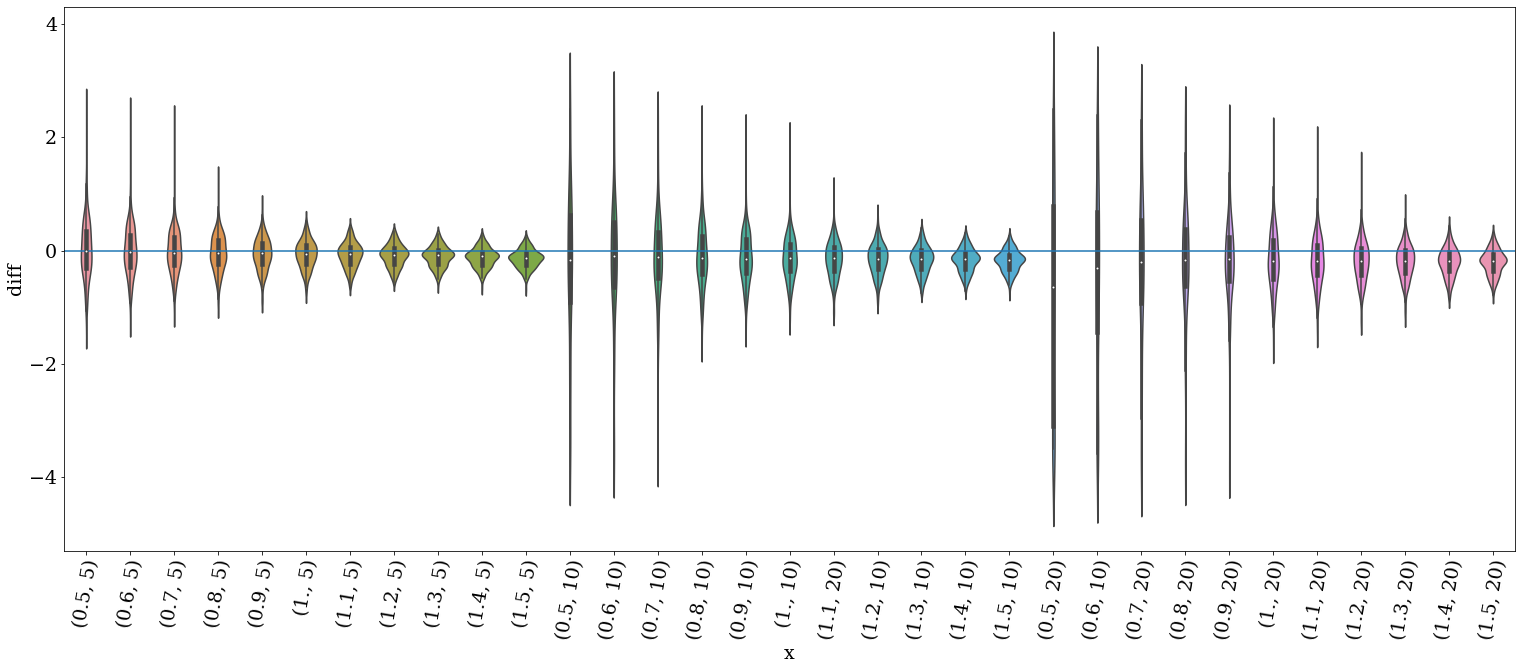

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(26, 10))

sns.violinplot(data=df, x="x", y="diff", ax=ax)


ax.set_xticks(x_axis) 
ax.set_xticklabels(['(0.5, 5)', '(0.6, 5)', '(0.7, 5)', '(0.8, 5)', '(0.9, 5)', 
                        '(1., 5)', '(1.1, 5)', '(1.2, 5)', '(1.3, 5)', '(1.4, 5)', '(1.5, 5)',
                       '(0.5, 10)', '(0.6, 10)', '(0.7, 10)', '(0.8, 10)', '(0.9, 10)', 
                        '(1., 10)', '(1.1, 20)', '(1.2, 10)', '(1.3, 10)', '(1.4, 10)', '(1.5, 10)', 
                        '(0.5, 20)', '(0.6, 10)', '(0.7, 20)', '(0.8, 20)', '(0.9, 20)', 
                        '(1., 20)', '(1.1, 20)', '(1.2, 20)', '(1.3, 20)', '(1.4, 20)', '(1.5, 20)', 
                       ], 
                   rotation=80);

ax.axhline(0.)
#ax.set_ylim(-0.6, 2.1)

(-0.5, 2.5)

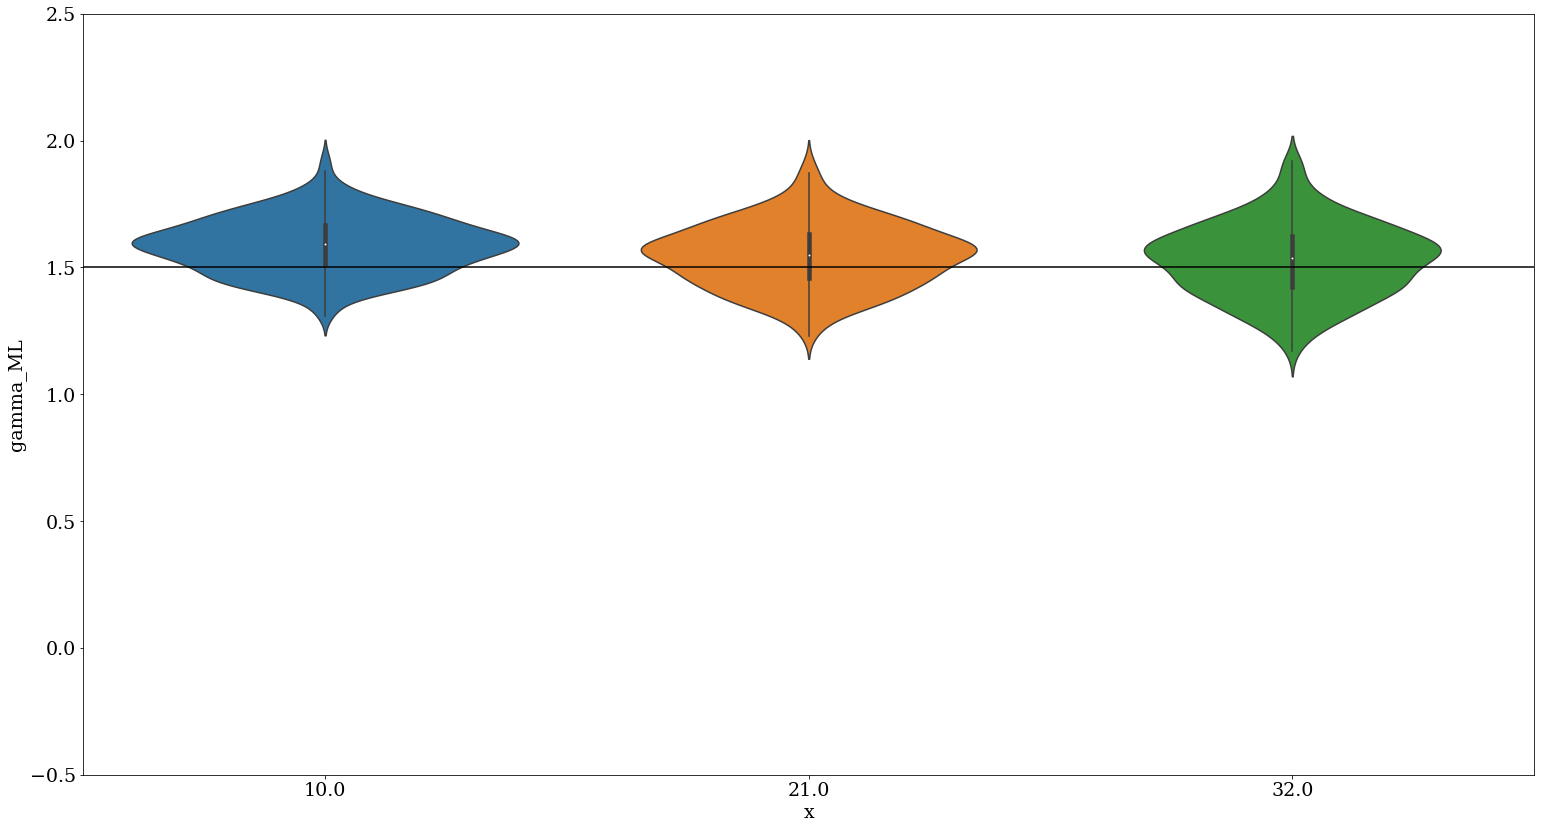

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(26, 14))

sns.violinplot(data=df[(df.x==10) | (df.x==21) | (df.x==32)], x="x", y="gamma_ML", ax=ax)

#ax.set_xticks(x_axis) 
#ax.set_xticklabels(['(0.5, 5)', '(0.6, 5)', '(0.7, 5)', '(0.8, 5)', '(0.9, 5)', 
#                        '(1., 5)', '(1.1, 5)', '(1.2, 5)', '(1.3, 5)', '(1.4, 5)', '(1.5, 5)',
#                       '(0.5, 10)', '(0.6, 10)', '(0.7, 10)', '(0.8, 10)', '(0.9, 10)', 
#                        '(1., 10)', '(1.1, 20)', '(1.2, 10)', '(1.3, 10)', '(1.4, 10)', '(1.5, 10)', 
#                        '(0.5, 20)', '(0.6, 10)', '(0.7, 20)', '(0.8, 20)', '(0.9, 20)', 
#                        '(1., 20)', '(1.1, 20)', '(1.2, 20)', '(1.3, 20)', '(1.4, 20)', '(1.5, 20)', 
#                       ], 
#                   rotation=80);

ax.axhline(1.5, color="k")
ax.set_ylim(-0.5, 2.5)

(-0.5, 2.5)

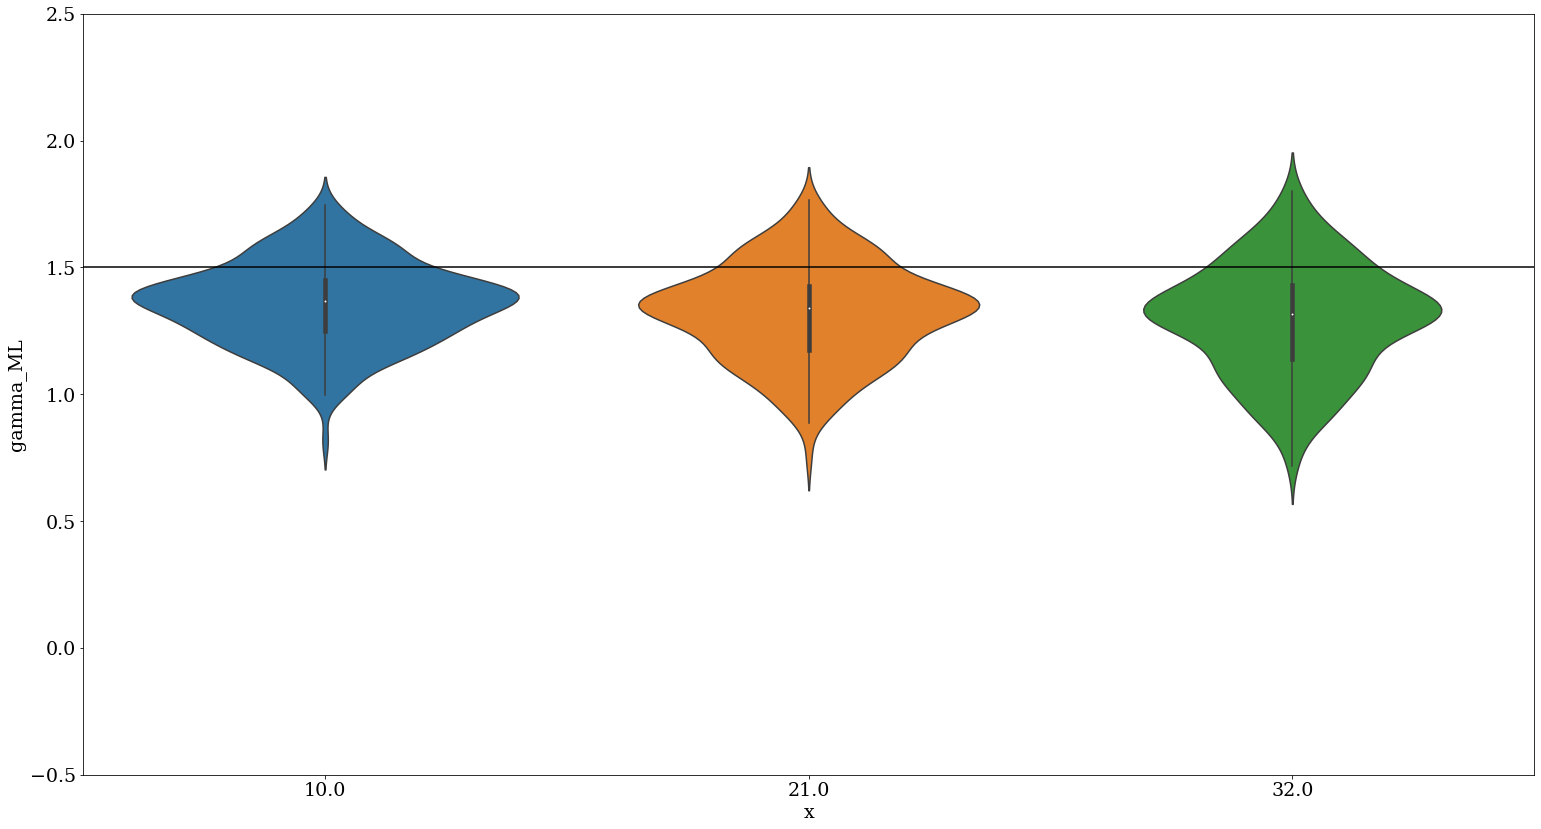

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(26, 14))
import seaborn as sns
sns.violinplot(data=df[(df.x==10) | (df.x==21) | (df.x==32)], x="x", y="gamma_ML", ax=ax)
ax.axhline(1.5, color="k")
ax.set_ylim(-0.5, 2.5)

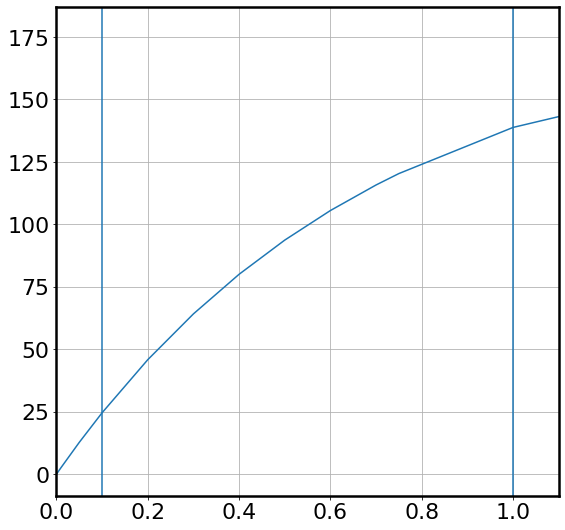

In [80]:
fig, ax = plt.subplots(1, 1, figsize=(9, 9))

path = "/home/mariacst/exoplanets/running/data/"

data = np.genfromtxt(path + "rc_e2bulge_R08.178_J_corr.dat", unpack=True)
r    = data[0]; vb = data[1]

data = np.genfromtxt(path + "rc_hgdisc_R08.178_corr.dat", unpack=True)
r    = data[0]; vd = data[1]

vtot = np.sqrt(np.power(vb, 2) + np.power(vd, 2)); ax.set_xlim(0, 1.1)
ax.grid()

ax.plot(r, vtot); ax.axvline(0.1); ax.axvline(1.)